# **PROJECT DATA MINING**
## Penerapan Stream Mining untuk Klasifikasi Tingkat Bahaya Gempa Bumi di Indonesia Menggunakan Hoeffding Tree dan Adaptive Random Forest dengan Deteksi Concept Drift Berbasis ADWIN

**Kelompok 5 – S1 Sains Data, Universitas Negeri Surabaya**
- Ayda' Nur Salzabillah (24031554017)
- Gresya Maranatha (24031554027)
- Muhammad Zikri Widiandra (24031554088)

**Kelas 2024B**

Dataset: https://www.kaggle.com/datasets/kekavigi/earthquakes-in-indonesia?select=katalog_gempa_v2.tsv

# **Import Library & Load Dataset**

In [ ]:
# !pip install river geopandas cartopy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from river import tree
from river import drift
from river import metrics
from river import stream
from river import forest

from IPython.display import Image, display

In [ ]:
df = pd.read_csv('katalog_gempa_v2.tsv', sep='\t')
print(df.head())

       eventID                          datetime  latitude   longitude  \
0  bmg2008vkye  2008-11-01 00:31:25.143741+00:00 -0.604440   98.895531   
1  bmg2008vlag  2008-11-01 01:34:29.660856+00:00 -6.611860  129.387220   
2  bmg2008vlaj  2008-11-01 01:38:14.802129+00:00 -3.650586  127.990680   
3  bmg2008vlbt  2008-11-01 02:20:05.909515+00:00 -4.198925  128.097000   
4  bmg2008vlcd  2008-11-01 02:32:18.756155+00:00 -4.091891  128.200470   

   magnitude mag_type  depth  phasecount  azimuth_gap  \
0   2.989742      MLv     20         6.0    146.70738   
1   5.507549       mb     30        62.0     45.46764   
2   3.539674      MLv      5         4.0    331.97404   
3   2.424314      MLv      5         5.0    326.37993   
4   2.410045      MLv     10         5.0    314.65474   

                      location  ... doubleCouple clvd  strikeNP1  dipNP1  \
0  Southern Sumatra, Indonesia  ...          NaN  NaN        NaN     NaN   
1                    Banda Sea  ...          NaN  NaN       

/tmp/ipykernel_10858/3878393980.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('katalog_gempa_v2.tsv', sep='\t')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131833 entries, 0 to 131832
Data columns (total 37 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   eventID            131833 non-null  object 
 1   datetime           131833 non-null  object 
 2   latitude           131833 non-null  float64
 3   longitude          131833 non-null  float64
 4   magnitude          131134 non-null  float64
 5   mag_type           131134 non-null  object 
 6   depth              131833 non-null  int64  
 7   phasecount         131831 non-null  float64
 8   azimuth_gap        131829 non-null  float64
 9   location           131817 non-null  object 
 10  agency             128390 non-null  object 
 11  datetimeFM         4607 non-null    object 
 12  latFM              4607 non-null    float64
 13  lonFM              4607 non-null    float64
 14  magFM              3908 non-null    float64
 15  magTypeFM          3908 non-null    object 
 16  de

## Filter Tahun 2015-2025

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'], format='ISO8601')

start_date = '2015-01-01'
end_date = '2025-10-01'

filtered_data = df[(df['datetime'] >= start_date) & (df['datetime'] <= end_date)]

print(f"Data sebelum filter: {len(df)} baris")
print(f"Data setelah filter ({start_date} sampai {end_date}): {len(filtered_data)} baris")
print(filtered_data.head())

Data sebelum filter: 131833 baris
Data setelah filter (2015-01-01 sampai 2025-10-01): 102258 baris
           eventID                         datetime   latitude   longitude  \
29549  bmg2015aaiz 2015-01-01 04:33:02.650568+00:00  -1.875930  120.303391   
29550  bmg2015aakf 2015-01-01 05:13:08.163493+00:00  -1.991261  120.411621   
29551  bmg2015aaya 2015-01-01 12:07:10.918619+00:00 -10.135225  113.839798   
29552  bmg2015aazj 2015-01-01 12:53:51.516325+00:00  -2.689607  129.363144   
29553  bmg2015abff 2015-01-01 15:45:50.473693+00:00  -9.322252  113.325302   

       magnitude mag_type  depth  phasecount  azimuth_gap  \
29549   3.326321      MLv     24        16.0   146.938171   
29550   3.435773      MLv     17        16.0   122.595734   
29551   4.250569      MLv     59        48.0   113.361114   
29552   4.259353      MLv     21        30.0    76.438179   
29553   4.174690      MLv     29        38.0   173.977303   

                       location  ... doubleCouple clvd  strikeNP1

## Filter Kolom

In [ ]:
kolom_digunakan = ['datetime', 'latitude', 'longitude', 'depth', 'phasecount', 'magnitude']
data = filtered_data[kolom_digunakan].copy()

print(data.head())

                              datetime   latitude   longitude  depth  \
29549 2015-01-01 04:33:02.650568+00:00  -1.875930  120.303391     24   
29550 2015-01-01 05:13:08.163493+00:00  -1.991261  120.411621     17   
29551 2015-01-01 12:07:10.918619+00:00 -10.135225  113.839798     59   
29552 2015-01-01 12:53:51.516325+00:00  -2.689607  129.363144     21   
29553 2015-01-01 15:45:50.473693+00:00  -9.322252  113.325302     29   

       phasecount  magnitude  
29549        16.0   3.326321  
29550        16.0   3.435773  
29551        48.0   4.250569  
29552        30.0   4.259353  
29553        38.0   4.174690  


Datetime digunakan untuk analisis temporal dan simulasi stream, latitude serta longitude digunakan untuk analisis geospasial, depth dan phasecount digunakan sebagai fitur karakteristik gempa, sedangkan magnitude digunakan untuk menentukan tingkat bahaya gempa yang menjadi target klasifikasi.

# **EDA AWAL**

## 1. Statistik Deskriptif

In [ ]:
print("=== Statistik Deskriptif ===")

print(data.describe())

=== Statistik Deskriptif ===
            latitude      longitude          depth     phasecount  \
count  102258.000000  102258.000000  102258.000000  102256.000000   
mean       -3.378842     119.536520      47.932954      25.406538   
std         4.314121      10.508503      78.506436      33.553763   
min       -11.231423      95.002388       0.000000       0.000000   
25%        -7.847391     115.087580      10.000000      11.000000   
50%        -2.850474     121.170868      15.000000      17.000000   
75%         0.110946     126.812708      49.000000      29.000000   
max         5.998937     140.998291     750.000000    1268.000000   

           magnitude  
count  101596.000000  
mean        3.419973  
std         0.821309  
min         0.191153  
25%         2.829158  
50%         3.353562  
75%         3.965991  
max         7.894698  


## 2. Cek Duplikat Data

Data duplikat dapat menyebabkan hasil analisis menjadi bias sehingga perlu dideteksi sejak awal.

In [ ]:
n_duplikat = data.duplicated().sum()
print(f"Duplikat ditemukan: {n_duplikat} baris")

Duplikat ditemukan: 0 baris


## 3. Cek Missing Value

In [ ]:
missing = pd.DataFrame({
    'dtype'  : data.dtypes,
    'jumlah' : data.isnull().sum(),
    'persen' : (data.isnull().sum() / len(data) * 100).round(2),
})
print(missing)

                          dtype  jumlah  persen
datetime    datetime64[ns, UTC]       0    0.00
latitude                float64       0    0.00
longitude               float64       0    0.00
depth                     int64       0    0.00
phasecount              float64       2    0.00
magnitude               float64     662    0.65


## 4. Distribusi Fitur Numerik

Visualisasi ini membantu melihat pola penyebaran data dan mengetahui apakah terdapat distribusi yang tidak normal atau nilai yang sangat ekstrem.

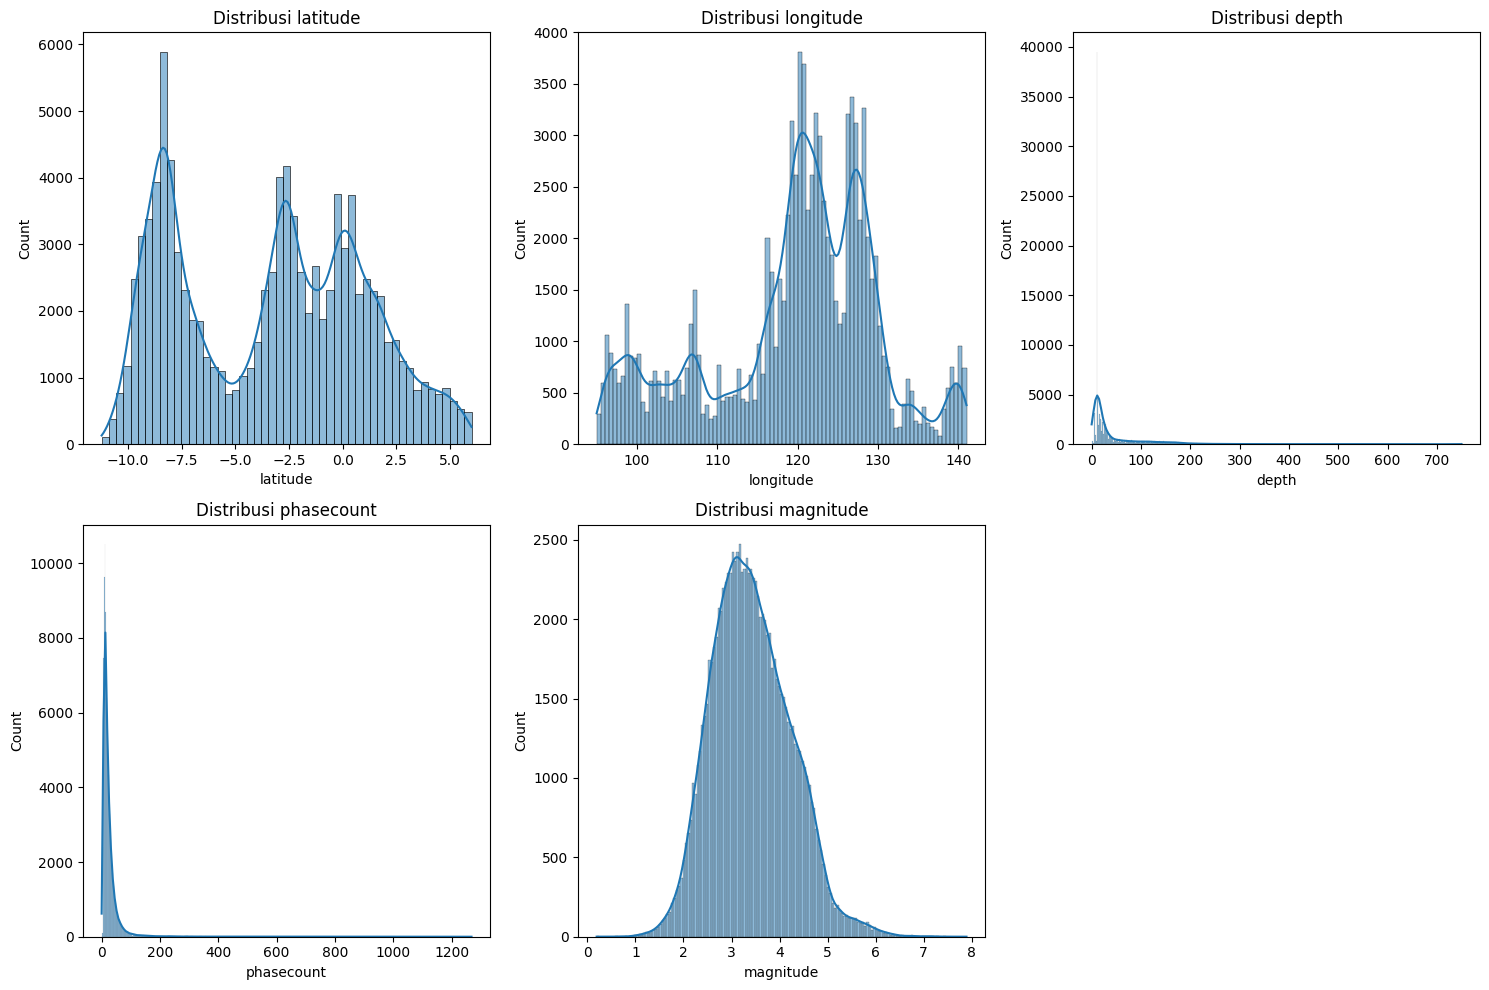

In [ ]:
fitur_numerik = ['latitude', 'longitude', 'depth', 'phasecount', 'magnitude']

plt.figure(figsize=(15,10))

for i, col in enumerate(fitur_numerik):

    plt.subplot(2,3,i+1)

    sns.histplot(data[col], kde=True)

    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

Dari visualisasi ini terlihat bahwa beberapa fitur seperti depth dan phasecount memiliki distribusi yang tidak normal dan mengandung nilai ekstrem. Oleh karena itu, pada tahap preprocessing dilakukan penanganan outlier agar kualitas data menjadi lebih baik sebelum digunakan dalam analisis dan pemodelan.

## 5. Cek Outlier

In [ ]:
fitur_numerik = ['latitude', 'longitude', 'depth', 'phasecount', 'magnitude']

print("=== Deteksi Outlier Menggunakan IQR ===\n")

for col in fitur_numerik:

    # Hitung Q1 dan Q3
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    # Hitung IQR
    IQR = Q3 - Q1

    # Batas bawah & atas
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    # Cari outlier
    outlier = data[(data[col] < batas_bawah) | (data[col] > batas_atas)]

    print(f"{col}")
    print(f"Jumlah Outlier : {len(outlier)}")
    print(f"Batas Bawah    : {batas_bawah:.2f}")
    print(f"Batas Atas     : {batas_atas:.2f}")
    print("-" * 40)

=== Deteksi Outlier Menggunakan IQR ===

latitude
Jumlah Outlier : 0
Batas Bawah    : -19.78
Batas Atas     : 12.05
----------------------------------------
longitude
Jumlah Outlier : 3559
Batas Bawah    : 97.50
Batas Atas     : 144.40
----------------------------------------
depth
Jumlah Outlier : 14410
Batas Bawah    : -48.50
Batas Atas     : 107.50
----------------------------------------
phasecount
Jumlah Outlier : 7096
Batas Bawah    : -16.00
Batas Atas     : 56.00
----------------------------------------
magnitude
Jumlah Outlier : 891
Batas Bawah    : 1.12
Batas Atas     : 5.67
----------------------------------------


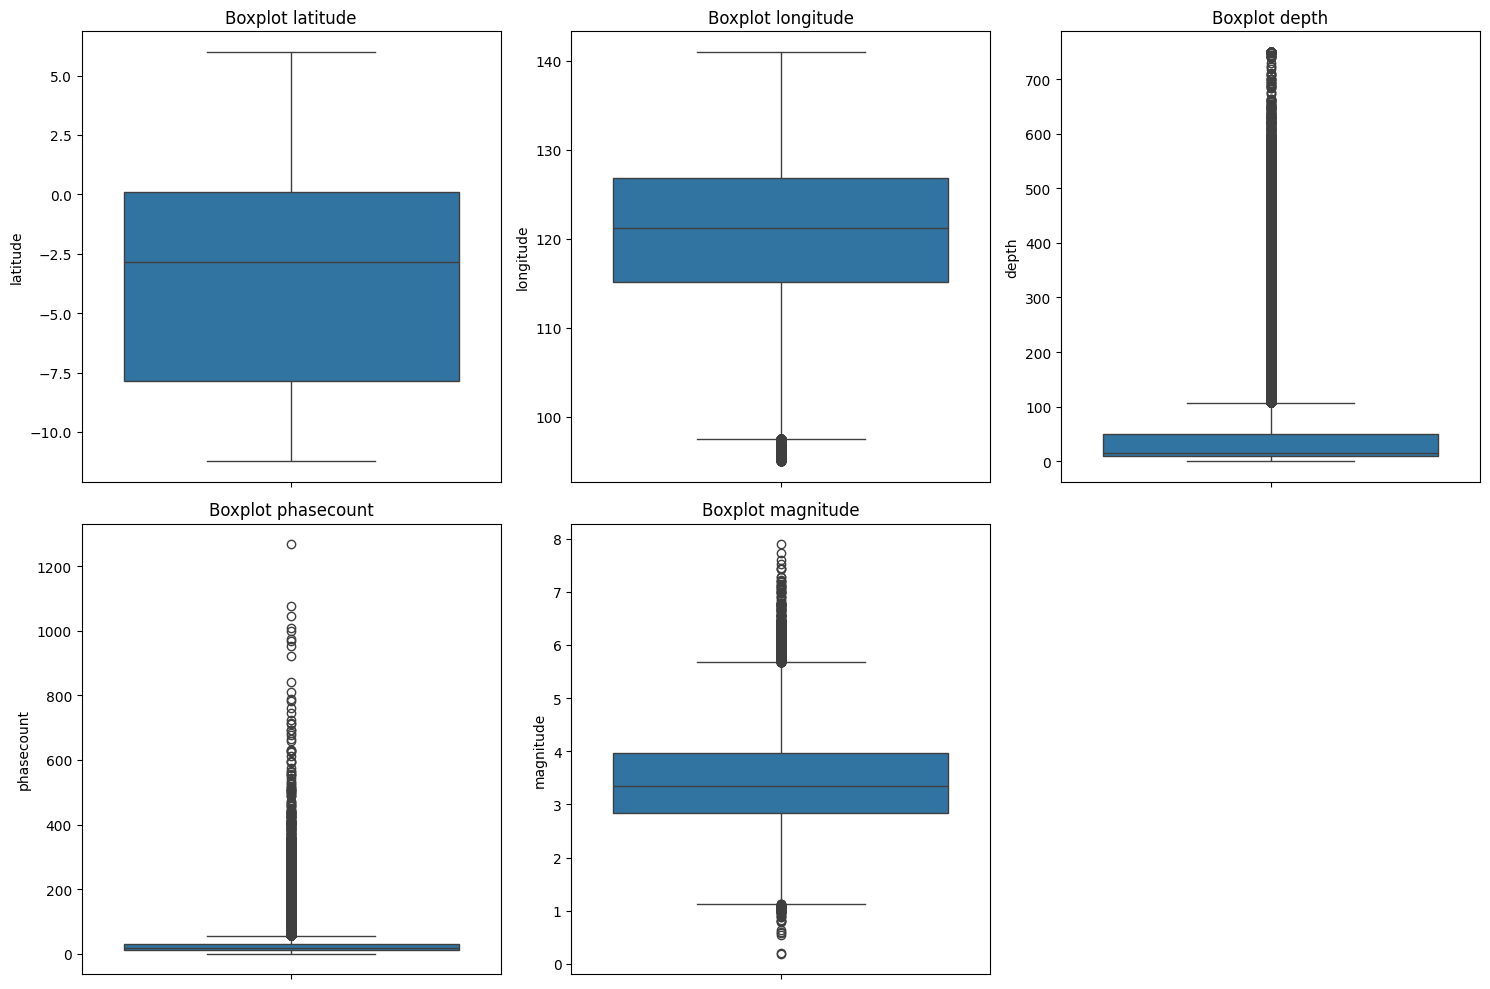

In [ ]:
plt.figure(figsize=(15,10))

for i, col in enumerate(fitur_numerik):

    plt.subplot(2,3,i+1)

    sns.boxplot(y=data[col])

    plt.title(f'Boxplot {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

## 6. Heatmap Korelasi

Nilai korelasi menunjukkan seberapa kuat hubungan antar fitur, sehingga dapat membantu memahami faktor-faktor yang berkaitan dengan karakteristik gempa.

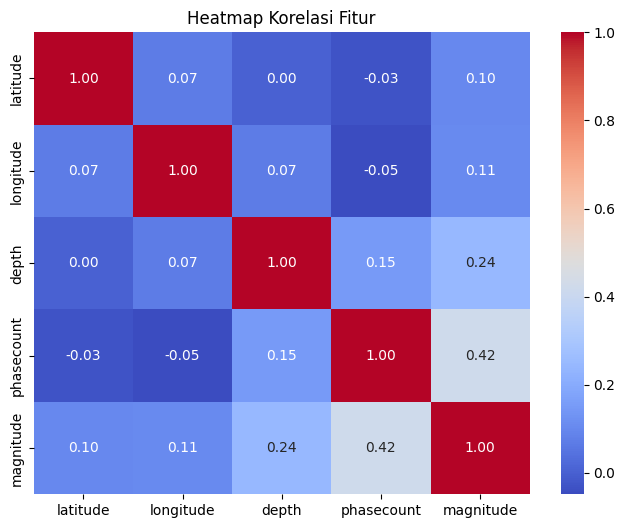

In [ ]:
plt.figure(figsize=(8,6))

corr = data[['latitude', 'longitude', 'depth',
             'phasecount', 'magnitude']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Heatmap Korelasi Fitur')
plt.show()

Secara keseluruhan tidak ditemukan multikolinearitas yang tinggi karena tidak ada pasangan fitur yang memiliki korelasi mendekati 1. Oleh karena itu, seluruh fitur masih layak digunakan dalam proses analisis dan pemodelan.

## 7. Distribusi Gempa per Tahun

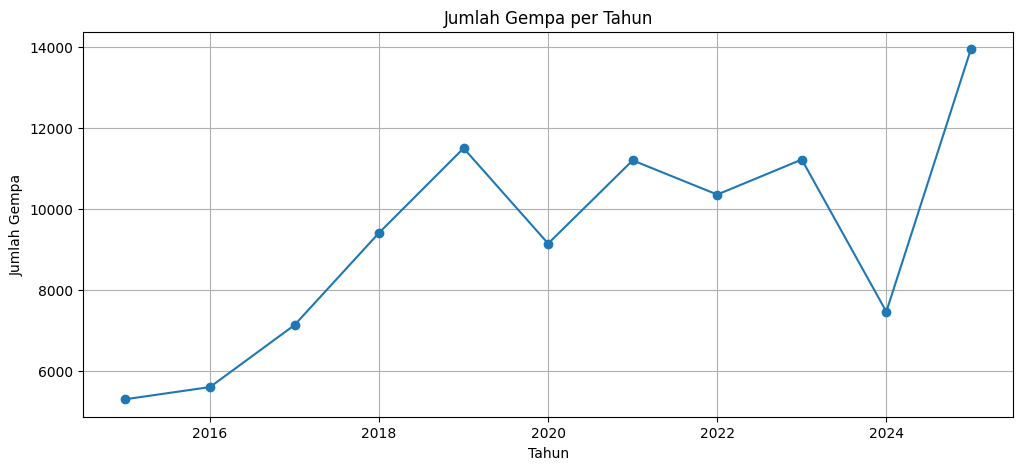

In [ ]:
gempa_per_tahun = data['datetime'].dt.year.value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.plot(
    gempa_per_tahun.index,
    gempa_per_tahun.values,
    marker='o'
)

plt.title('Jumlah Gempa per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Gempa')

plt.grid(True)
plt.show()

Jumlah gempa per tahun menunjukkan pola fluktuatif dengan kecenderungan meningkat, sehingga data gempa cocok dianalisis menggunakan pendekatan stream mining yang mampu memproses data secara berkelanjutan.

# **Pre-Processing**

## 1. Penanganan Missing Value

Missing value pada atribut phasecount dan magnitude ditangani menggunakan median karena metode ini lebih tahan terhadap outlier dibandingkan rata-rata.

In [ ]:
NUMERIK = ['phasecount', 'magnitude']

for kolom in NUMERIK:
    median_val = data[kolom].median()
    n_isi      = data[kolom].isnull().sum()
    if n_isi > 0:
        data[kolom] = data[kolom].fillna(median_val)
        print(f"  [{kolom:<12}] diisi {n_isi} nilai → median = {median_val:.4f}")

print(f"\nTotal missing setelah imputasi: {data.isnull().sum().sum()}")


  [phasecount  ] diisi 2 nilai → median = 17.0000
  [magnitude   ] diisi 662 nilai → median = 3.3536

Total missing setelah imputasi: 0


## 2. Penanganan Outlier

In [ ]:
fitur_outlier = ['longitude', 'depth', 'phasecount']

for col in fitur_outlier:

    # Hitung Q1 dan Q3
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    # Hitung IQR
    IQR = Q3 - Q1

    # Tentukan batas bawah & atas
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    # Capping outlier bawah
    data[col] = np.where(
        data[col] < batas_bawah,
        batas_bawah,
        data[col]
    )

    # Capping outlier atas
    data[col] = np.where(
        data[col] > batas_atas,
        batas_atas,
        data[col]
    )

print("Penanganan outlier selesai.")

Penanganan outlier selesai.


In [ ]:
print("=== Outlier Setelah Penanganan ===\n")

fitur_numerik = ['latitude', 'longitude', 'depth', 'phasecount']

for col in fitur_numerik:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    outlier = data[
        (data[col] < batas_bawah) |
        (data[col] > batas_atas)
    ]

    print(f"{col}")
    print(f"Jumlah Outlier : {len(outlier)}")
    print("-" * 35)

=== Outlier Setelah Penanganan ===

latitude
Jumlah Outlier : 0
-----------------------------------
longitude
Jumlah Outlier : 0
-----------------------------------
depth
Jumlah Outlier : 0
-----------------------------------
phasecount
Jumlah Outlier : 0
-----------------------------------


Magnitude tidak dilakukan penanganan outlier karena nilai magnitudo yang tinggi bukan merupakan kesalahan data, melainkan kejadian gempa yang memang benar-benar terjadi dan memiliki informasi penting terkait tingkat bahaya gempa.

## 4. Validasi Domain

validasi domain berdasarkan batas geografis Indonesia dan karakteristik gempa bumi.

Sebagai contoh, magnitudo dibatasi antara 0 hingga 12, kedalaman antara 0 hingga 700 kilometer, serta koordinat latitude dan longitude harus berada dalam wilayah Indonesia.

In [ ]:
DOMAIN = {
    'magnitude' : (0, 12),  # rentang umum skala magnitudo gempa
    'depth'     : (0, 700), # kedalaman gempa bumi menurut BMKG
    'latitude'  : (-11, 6), # batas lintang wilayah Indonesia
    'longitude' : (95, 141) # batas bujur wilayah Indonesia
}

# Membuat mask tiap kolom
mask_per_kolom = {
    kolom: (data[kolom] < batas[0]) | (data[kolom] > batas[1])
    for kolom, batas in DOMAIN.items()
}

# Gabungkan semua kondisi invalid
mask_invalid = pd.concat(mask_per_kolom, axis=1).any(axis=1)

# Simpan data invalid SEBELUM dihapus
baris_invalid = data[mask_invalid].copy()

# Tambahkan penanda kolom yang invalid
for kolom, mask in mask_per_kolom.items():
    baris_invalid[f'invalid_{kolom}'] = mask[mask_invalid].values

# Tampilkan data invalid
print(f"Jumlah baris tidak valid: {mask_invalid.sum()}\n")

if len(baris_invalid) > 0:
    print(baris_invalid.to_string())
else:
    print("Tidak ada data di luar domain valid.")

Jumlah baris tidak valid: 1

                               datetime   latitude   longitude  depth  phasecount  magnitude  invalid_magnitude  invalid_depth  invalid_latitude  invalid_longitude
124723 2025-05-19 21:36:07.774174+00:00 -11.231423  111.079414   10.0        56.0    4.77595              False          False              True              False


In [ ]:
data = data[~mask_invalid].reset_index(drop=True)

print("\nJumlah data setelah validasi:", len(data))


Jumlah data setelah validasi: 102257


Pada tahap validasi domain ditemukan satu data yang tidak valid, yaitu memiliki nilai latitude sebesar -11,23 yang berada di luar batas wilayah Indonesia yang telah ditetapkan, yaitu -11 hingga 6 derajat. Karena data tersebut tidak memenuhi domain yang ditentukan, maka baris data tersebut dihapus dari dataset. Setelah dilakukan penghapusan, validasi ulang menunjukkan tidak ada lagi data yang berada di luar domain sehingga seluruh data telah memenuhi kriteria validitas.

In [ ]:
DOMAIN = {
    'magnitude' : (0, 12),
    'depth'     : (0, 700),
    'latitude'  : (-11, 6),
    'longitude' : (95, 141)
}

# Membuat mask invalid ulang setelah data dibersihkan
mask_per_kolom_after = {
    kolom: (data[kolom] < batas[0]) | (data[kolom] > batas[1])
    for kolom, batas in DOMAIN.items()
}

# Gabungkan semua kondisi invalid
mask_invalid_after = pd.concat(mask_per_kolom_after, axis=1).any(axis=1)

# Ambil data invalid jika masih ada
baris_invalid_after = data[mask_invalid_after]

# Tampilkan hasil
print("=== HASIL VALIDASI SETELAH PENANGANAN ===")
print(f"Jumlah data invalid: {mask_invalid_after.sum()}")

if len(baris_invalid_after) > 0:
    print("\nData yang masih invalid:")
    print(baris_invalid_after.to_string())
else:
    print("\nTidak ada data invalid. Semua data sudah sesuai domain.")

=== HASIL VALIDASI SETELAH PENANGANAN ===
Jumlah data invalid: 0

Tidak ada data invalid. Semua data sudah sesuai domain.


## 5. Urutan Kronologis

In [ ]:
data = data.sort_values('datetime').reset_index(drop=True)
print(f"Rentang: {data['datetime'].min()} → {data['datetime'].max()}")

Rentang: 2015-01-01 04:33:02.650568+00:00 → 2025-09-30 23:34:13.404875+00:00


Setelah seluruh proses pembersihan data selesai, data kemudian diurutkan berdasarkan kolom datetime dari waktu paling lama ke waktu paling baru

Hasilnya menunjukkan bahwa data gempa yang digunakan memiliki rentang waktu dari 1 Januari 2015 hingga 30 September 2025.

Pengurutan ini sangat penting karena penelitian menggunakan pendekatan data stream mining. Pada data stream, data harus masuk secara berurutan sesuai waktu kejadiannya agar menyerupai kondisi nyata, di mana data gempa terus mengalir dari waktu ke waktu.

## Ringkasan Setelah Pre-Processing

In [ ]:
print("=== DATASET SETELAH PREPROCESSING ===")
print(f"Jumlah data : {len(data)}")
print(f"Jumlah kolom: {data.shape[1]}")

print("\nTipe data:")
print(data.dtypes)

print("\n5 Data Teratas:")
print(data.head())

=== DATASET SETELAH PREPROCESSING ===
Jumlah data : 102257
Jumlah kolom: 6

Tipe data:
datetime      datetime64[ns, UTC]
latitude                  float64
longitude                 float64
depth                     float64
phasecount                float64
magnitude                 float64
dtype: object

5 Data Teratas:
                          datetime   latitude   longitude  depth  phasecount  \
0 2015-01-01 04:33:02.650568+00:00  -1.875930  120.303391   24.0        16.0   
1 2015-01-01 05:13:08.163493+00:00  -1.991261  120.411621   17.0        16.0   
2 2015-01-01 12:07:10.918619+00:00 -10.135225  113.839798   59.0        48.0   
3 2015-01-01 12:53:51.516325+00:00  -2.689607  129.363144   21.0        30.0   
4 2015-01-01 15:45:50.473693+00:00  -9.322252  113.325302   29.0        38.0   

   magnitude  
0   3.326321  
1   3.435773  
2   4.250569  
3   4.259353  
4   4.174690  


# **EDA Setelah Pre-processing**

## 1. Statistik Deskriptif Setelah Cleaning

In [ ]:
print("=== DATASET SETELAH PREPROCESSING ===")

print(f"Jumlah data : {len(data)}")
print(f"Jumlah kolom: {data.shape[1]}")

print("\nTipe data:")
print(data.dtypes)

print("\nStatistik deskriptif:")
print(data.describe())

=== DATASET SETELAH PREPROCESSING ===
Jumlah data : 102257
Jumlah kolom: 6

Tipe data:
datetime      datetime64[ns, UTC]
latitude                  float64
longitude                 float64
depth                     float64
phasecount                float64
magnitude                 float64
dtype: object

Statistik deskriptif:
            latitude      longitude          depth     phasecount  \
count  102257.000000  102257.000000  102257.000000  102257.000000   
mean       -3.378765     119.574241      34.977821      21.747528   
std         4.314072      10.426666      36.075469      14.584451   
min       -10.998470      97.499887       0.000000       0.000000   
25%        -7.847384     115.088661      10.000000      11.000000   
50%        -2.850368     121.170898      15.000000      17.000000   
75%         0.110971     126.812714      49.000000      29.000000   
max         5.998937     140.998291     107.500000      56.000000   

           magnitude  
count  102257.000000  
mean

## 2. Cek Missing Value Setelah Cleaning

In [ ]:
print("=== Missing Value Setelah Preprocessing ===")

print(data.isnull().sum())

=== Missing Value Setelah Preprocessing ===
datetime      0
latitude      0
longitude     0
depth         0
phasecount    0
magnitude     0
dtype: int64


## 3. Boxplot Setelah Penanganan Outlier

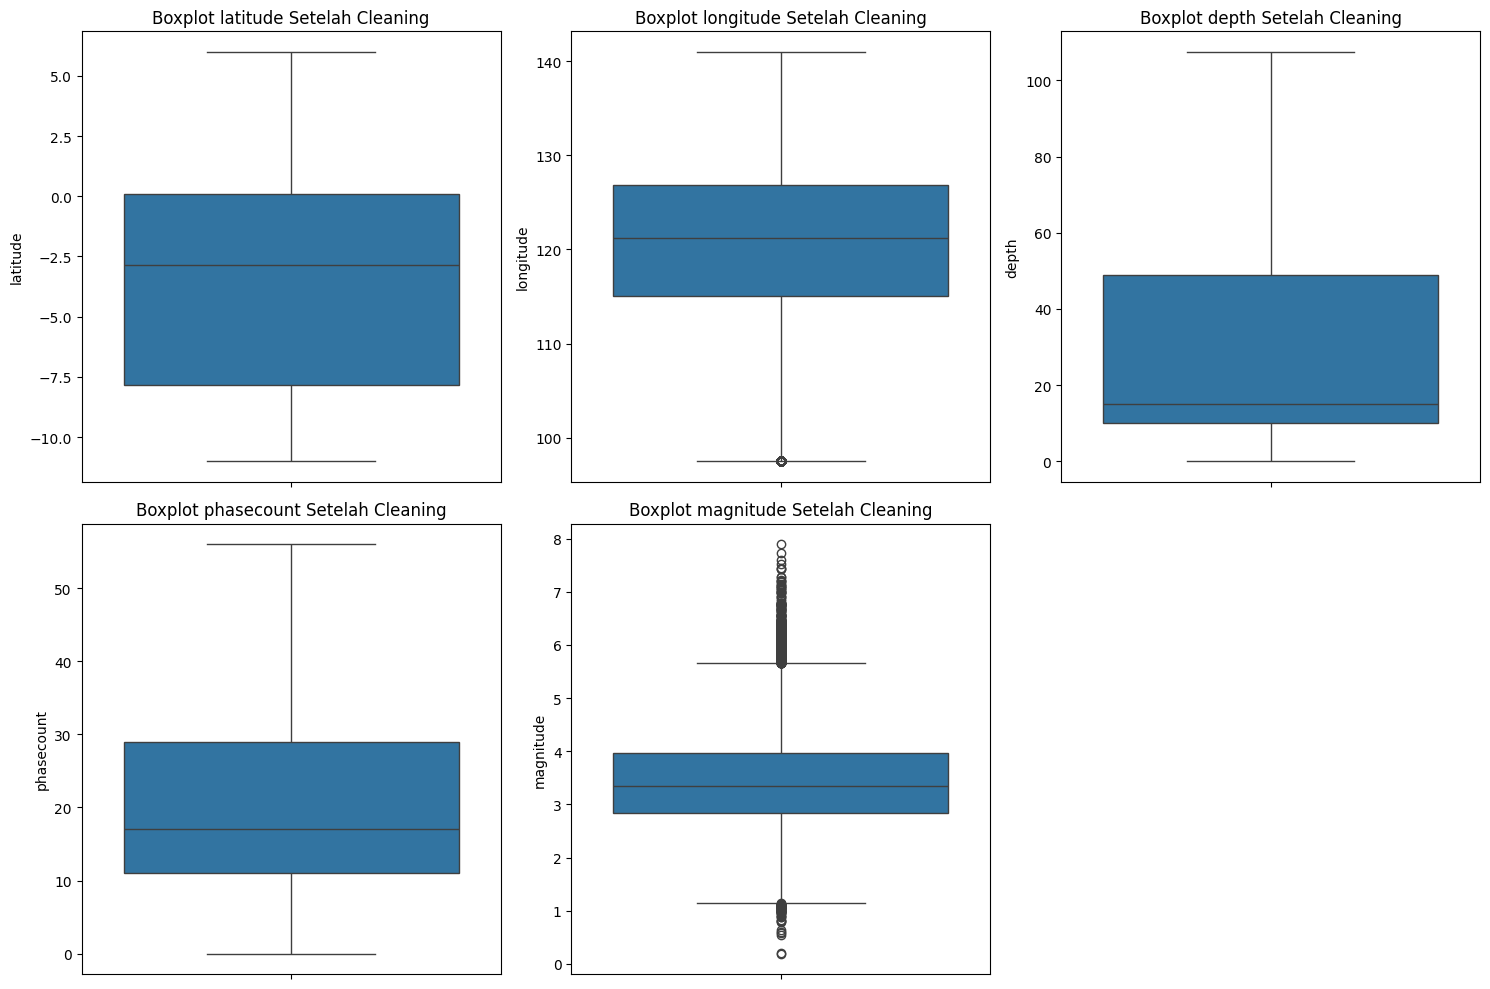

In [ ]:
fitur_numerik = [
    'latitude',
    'longitude',
    'depth',
    'phasecount',
    'magnitude'
]

plt.figure(figsize=(15,10))

for i, col in enumerate(fitur_numerik):

    plt.subplot(2,3,i+1)

    sns.boxplot(y=data[col])

    plt.title(f'Boxplot {col} Setelah Cleaning')

plt.tight_layout()
plt.show()

## 4. Distribusi Data Setelah Cleaning

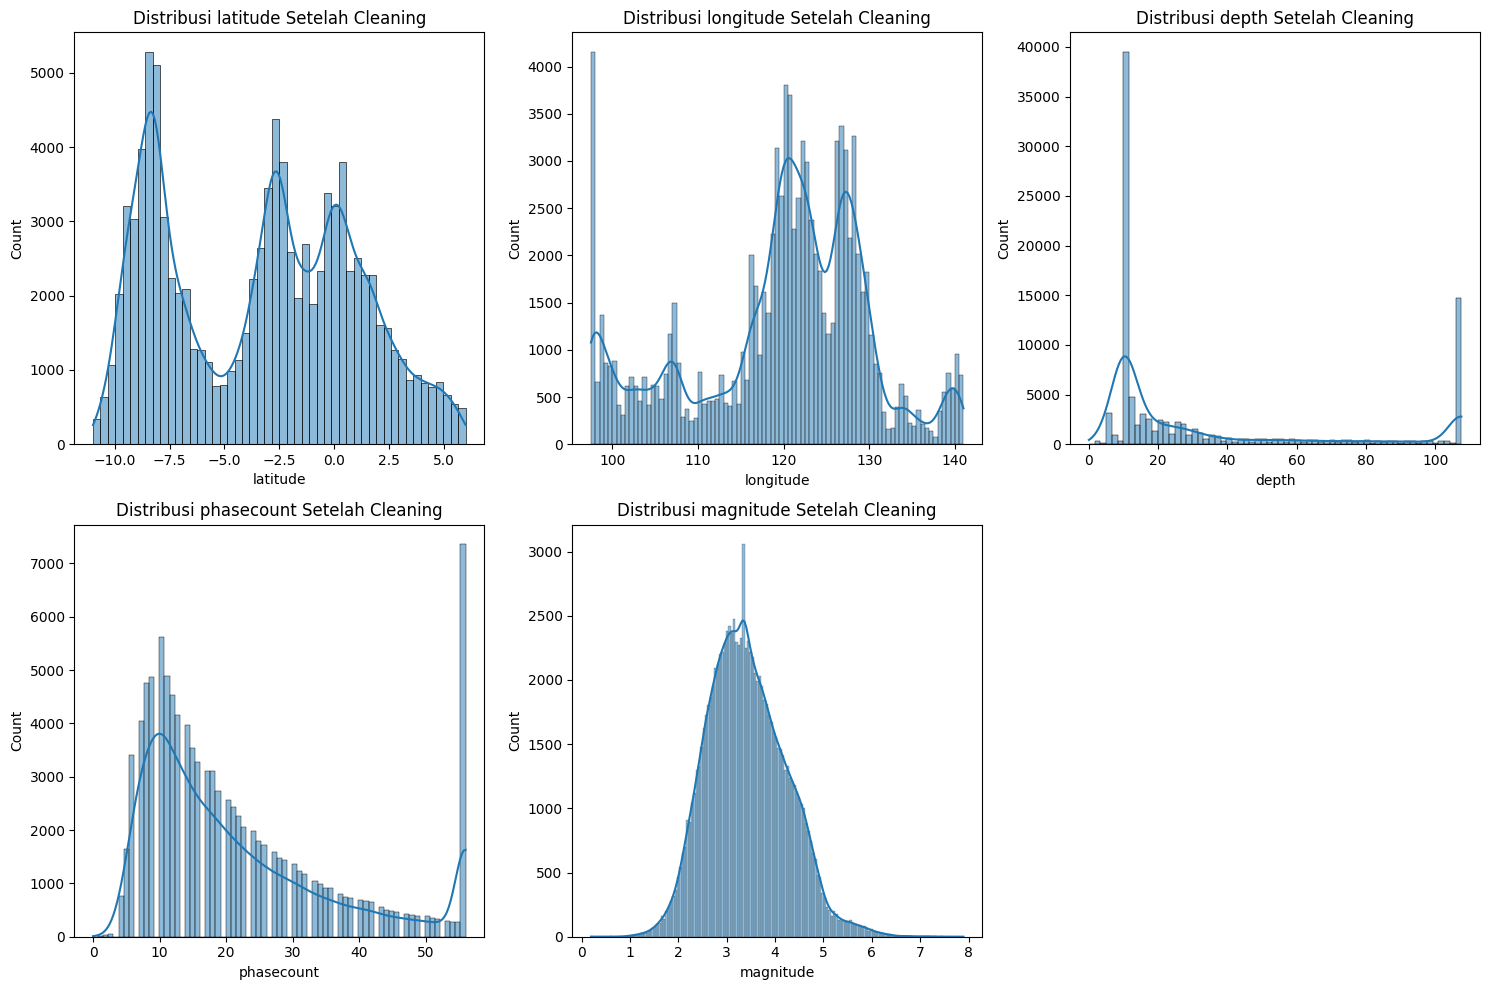

In [ ]:
plt.figure(figsize=(15,10))

for i, col in enumerate(fitur_numerik):

    plt.subplot(2,3,i+1)

    sns.histplot(data[col], kde=True)

    plt.title(f'Distribusi {col} Setelah Cleaning')

plt.tight_layout()
plt.show()

## 5. Heatmap Korelasi Setelah Cleaning

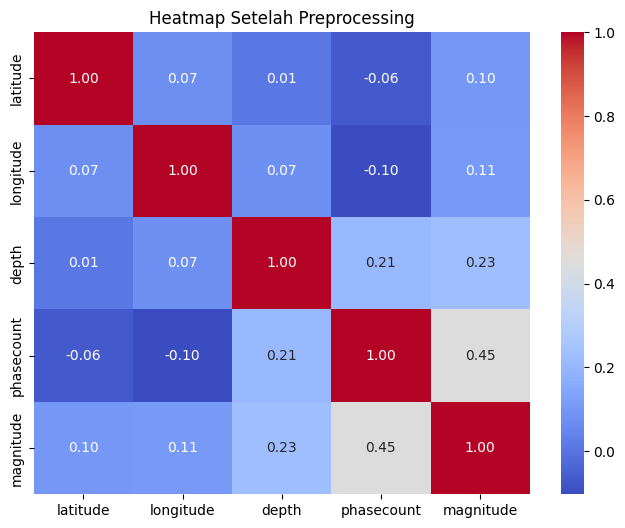

In [ ]:
plt.figure(figsize=(8,6))

corr_after = data[['latitude', 'longitude',
                   'depth', 'phasecount',
                   'magnitude']].corr()

sns.heatmap(
    corr_after,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Heatmap Setelah Preprocessing')
plt.show()

# **Labelling Tingkat Bahaya Gempa**

Label tingkat bahaya gempa dibuat berdasarkan nilai magnitudo karena dataset tidak memiliki target kelas secara langsung. Kategori dibagi menjadi empat kelas, yaitu Rendah (<3.0), Sedang (3.0–4.9), Tinggi (5.0–6.9), dan Ekstrem (≥7.0). Proses ini bertujuan untuk menghasilkan target klasifikasi yang akan digunakan oleh model stream mining dalam memprediksi tingkat bahaya gempa bumi di Indonesia.

## 1. Pembuatan Label

In [ ]:
# Fungsi kategorisasi tingkat bahaya
def kategori_bahaya(mag):

    if mag < 3.0:
        return 'Rendah'

    elif mag < 5.0:
        return 'Sedang'

    elif mag < 7.0:
        return 'Tinggi'

    else:
        return 'Ekstrem'


# Membuat kolom label
data['tingkat_bahaya'] = data['magnitude'].apply(kategori_bahaya)

# Tampilkan hasil
print("=== Contoh Data Setelah Labeling ===")
print(data[['magnitude', 'tingkat_bahaya']].head(10))

=== Contoh Data Setelah Labeling ===
   magnitude tingkat_bahaya
0   3.326321         Sedang
1   3.435773         Sedang
2   4.250569         Sedang
3   4.259353         Sedang
4   4.174690         Sedang
5   4.145435         Sedang
6   4.515163         Sedang
7   3.512719         Sedang
8   4.805480         Sedang
9   4.243217         Sedang


## 2. Cek Distribusi Label

In [ ]:
distribusi = data['tingkat_bahaya'].value_counts()
print(distribusi)

tingkat_bahaya
Sedang     65782
Rendah     33393
Tinggi      3057
Ekstrem       25
Name: count, dtype: int64


## 3. Visualisasi Distribusi Label

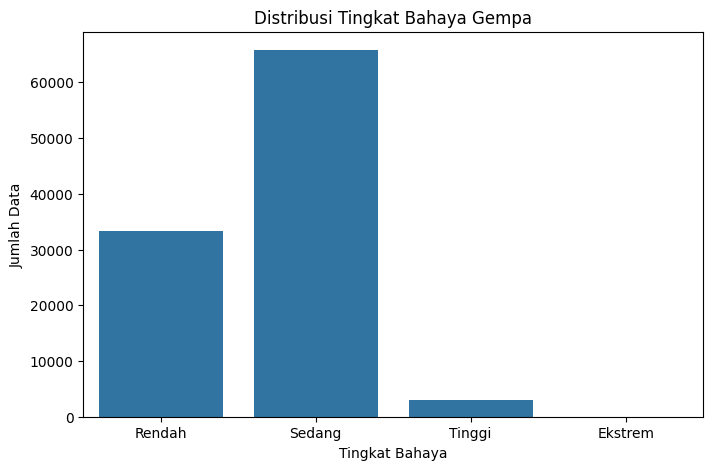

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x='tingkat_bahaya',
    order=['Rendah', 'Sedang', 'Tinggi', 'Ekstrem']
)

plt.title('Distribusi Tingkat Bahaya Gempa')
plt.xlabel('Tingkat Bahaya')
plt.ylabel('Jumlah Data')

plt.show()

## 4. Encoding Label

Kemudian label kategorikal diubah menjadi bentuk numerik agar dapat diproses oleh algoritma machine learning.

In [ ]:
label_mapping = {
    'Rendah' : 0,
    'Sedang' : 1,
    'Tinggi' : 2,
    'Ekstrem': 3
}

data['label'] = data['tingkat_bahaya'].map(label_mapping)

# Tampilkan hasil
print(data[['magnitude', 'tingkat_bahaya', 'label']].head(10))

   magnitude tingkat_bahaya  label
0   3.326321         Sedang      1
1   3.435773         Sedang      1
2   4.250569         Sedang      1
3   4.259353         Sedang      1
4   4.174690         Sedang      1
5   4.145435         Sedang      1
6   4.515163         Sedang      1
7   3.512719         Sedang      1
8   4.805480         Sedang      1
9   4.243217         Sedang      1


## Cek Hasil Dataset

In [ ]:
print(data.head())

print("\nInformasi Dataset:")
print(data.info())

                          datetime   latitude   longitude  depth  phasecount  \
0 2015-01-01 04:33:02.650568+00:00  -1.875930  120.303391   24.0        16.0   
1 2015-01-01 05:13:08.163493+00:00  -1.991261  120.411621   17.0        16.0   
2 2015-01-01 12:07:10.918619+00:00 -10.135225  113.839798   59.0        48.0   
3 2015-01-01 12:53:51.516325+00:00  -2.689607  129.363144   21.0        30.0   
4 2015-01-01 15:45:50.473693+00:00  -9.322252  113.325302   29.0        38.0   

   magnitude tingkat_bahaya  label  
0   3.326321         Sedang      1  
1   3.435773         Sedang      1  
2   4.250569         Sedang      1  
3   4.259353         Sedang      1  
4   4.174690         Sedang      1  

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102257 entries, 0 to 102256
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   datetime        102257 non-null  datetime64[ns

# **Simulasi Data Stream**

Simulasi data stream dilakukan dengan membaca dataset gempa bumi secara berurutan berdasarkan waktu kejadian. Setiap baris data diproses satu per satu sehingga menyerupai aliran data real-time. Pada tahap ini, atribut waktu (datetime) diubah menjadi fitur numerik berupa tahun, bulan, hari, dan jam agar dapat diproses oleh model machine learning. Setiap data stream terdiri dari sekumpulan fitur gempa dan label tingkat bahaya yang akan digunakan pada proses klasifikasi incremental menggunakan Hoeffding Tree dan Adaptive Random Forest.

## 1. Feature Extraction Datatime

Mengubah datetime menjadi fitur numerik agar dapat diproses model machine learning

In [ ]:
# Mengubah datetime menjadi fitur numerik
data['year']  = data['datetime'].dt.year
data['month'] = data['datetime'].dt.month
data['day']   = data['datetime'].dt.day
data['hour']  = data['datetime'].dt.hour

print("=== Feature Extraction Datetime ===")
print(data[['datetime', 'year', 'month', 'day', 'hour']].head())

=== Feature Extraction Datetime ===
                          datetime  year  month  day  hour
0 2015-01-01 04:33:02.650568+00:00  2015      1    1     4
1 2015-01-01 05:13:08.163493+00:00  2015      1    1     5
2 2015-01-01 12:07:10.918619+00:00  2015      1    1    12
3 2015-01-01 12:53:51.516325+00:00  2015      1    1    12
4 2015-01-01 15:45:50.473693+00:00  2015      1    1    15


## 2. Menentukan Fitur dan Target

magnitude tidak digunakan sebagai fitur karena label dibuat dari magnitude untuk menghindari data leakage

In [ ]:
fitur = ['latitude', 'longitude', 'depth', 'phasecount', 'year', 'month', 'day', 'hour']

target = 'label'

X = data[fitur]
y = data[target]

print("\n=== Informasi Dataset Stream ===")
print("\nJumlah data:", len(X))

print("\nJumlah data:")
print(len(X))

print("\nJumlah fitur:")
print(len(fitur))

print("\nNama fitur:")
print(fitur)

print("\nContoh fitur:")
print(X.head())

print("\nContoh target:")
print(y.head())



=== Informasi Dataset Stream ===

Jumlah data: 102257

Jumlah data:
102257

Jumlah fitur:
8

Nama fitur:
['latitude', 'longitude', 'depth', 'phasecount', 'year', 'month', 'day', 'hour']

Contoh fitur:
    latitude   longitude  depth  phasecount  year  month  day  hour
0  -1.875930  120.303391   24.0        16.0  2015      1    1     4
1  -1.991261  120.411621   17.0        16.0  2015      1    1     5
2 -10.135225  113.839798   59.0        48.0  2015      1    1    12
3  -2.689607  129.363144   21.0        30.0  2015      1    1    12
4  -9.322252  113.325302   29.0        38.0  2015      1    1    15

Contoh target:
0    1
1    1
2    1
3    1
4    1
Name: label, dtype: int64


## 3. Membuat Simulasi Data Stream

In [ ]:
data_stream = stream.iter_pandas(X, y)

## 4. Menampilkan Contoh Aliran Data Stream

In [ ]:
print("\n=== Contoh Simulasi Data Stream ===\n")

for i, (x_stream, y_stream) in enumerate(stream.iter_pandas(X, y)):

    print(f"Data Stream ke-{i+1}")

    print("\nFitur:")
    print(x_stream)

    print("\nLabel:")
    print(y_stream)

    print("-" * 50)

    # tampilkan hanya 5 data pertama
    if i == 4:
        break


=== Contoh Simulasi Data Stream ===

Data Stream ke-1

Fitur:
{'latitude': -1.875930071, 'longitude': 120.3033905, 'depth': 24.0, 'phasecount': 16.0, 'year': 2015.0, 'month': 1.0, 'day': 1.0, 'hour': 4.0}

Label:
1
--------------------------------------------------
Data Stream ke-2

Fitur:
{'latitude': -1.991261363, 'longitude': 120.4116211, 'depth': 17.0, 'phasecount': 16.0, 'year': 2015.0, 'month': 1.0, 'day': 1.0, 'hour': 5.0}

Label:
1
--------------------------------------------------
Data Stream ke-3

Fitur:
{'latitude': -10.1352253, 'longitude': 113.839798, 'depth': 59.0, 'phasecount': 48.0, 'year': 2015.0, 'month': 1.0, 'day': 1.0, 'hour': 12.0}

Label:
1
--------------------------------------------------
Data Stream ke-4

Fitur:
{'latitude': -2.689607143, 'longitude': 129.3631439, 'depth': 21.0, 'phasecount': 30.0, 'year': 2015.0, 'month': 1.0, 'day': 1.0, 'hour': 12.0}

Label:
1
--------------------------------------------------
Data Stream ke-5

Fitur:
{'latitude': -9.32225

## 5. Informasi Stream

In [ ]:
print("\n=== Informasi Stream ===")

print("Tipe data_stream :", type(data_stream))


=== Informasi Stream ===
Tipe data_stream : <class 'generator'>


Data diubah menjadi tipe `generator` agar dapat diproses secara bertahap seperti aliran data real-time. Dengan menggunakan generator, setiap data gempa akan dibaca satu per satu sesuai urutan waktu, sehingga model dapat melakukan prediksi, evaluasi, dan pembelajaran secara incremental tanpa memproses seluruh data sekaligus.

## 6. Reset Stream Untuk Modelling

Stream perlu dibuat ulang sebelum modeling karena iterator akan habis setelah digunakan

In [ ]:
data_stream = stream.iter_pandas(X, y)

print("\nData stream berhasil disiapkan untuk tahap modeling.")


Data stream berhasil disiapkan untuk tahap modeling.


# **Pembangunan Model**

## **HF (HOEFFDING TREE)**



Hoeffding Tree merupakan algoritma decision tree yang dirancang khusus untuk data stream atau data yang mengalir secara terus menerus. Hoeffding Tree mempelajari data secara bertahap (incremental learning). Model ini akan memperbarui struktur tree setiap kali data baru masuk tanpa perlu melakukan pelatihan ulang dari awal.

Membuat model klasifikasi menggunakan algoritma Hoeffding Tree

In [ ]:
# MEMBUAT MODEL HOEFFDING TREE
model_ht  = tree.HoeffdingTreeClassifier()

Membuat ADWIN untuk deteksi concept drift yang dapat mendeteksi perubahan pola pada selama proses setream berlangsung.

In [ ]:
# MEMBUAT ADWIN
adwin_ht  = drift.ADWIN()

Membuat metrik evaluasi menggunakan akurasi.

In [ ]:
metric_ht = metrics.Accuracy()
precision_ht = metrics.MacroPrecision()
recall_ht    = metrics.MacroRecall()
f1_ht        = metrics.MacroF1()

Inisialisasi variabel

In [ ]:
t = 0
drift_ht = 0
prev_nodes = 1

akurasi_ht_list = [] # Initialize list for HT accuracy
data_ke_ht = []    # Initialize list for HT step numbers

print(model_ht.summary)
print("Initial Accuracy :", metric_ht.get())

{'n_nodes': None, 'n_branches': None, 'n_leaves': None, 'n_active_leaves': 0, 'n_inactive_leaves': 0, 'height': 0, 'total_observed_weight': 0.0}
Initial Accuracy : 0.0


Melakukan update model untuk prediksi, evaluasi, deteksi drift dan pembelajaran model.

In [ ]:
# Tambah ini sebelum loop
hasil_drift_log = []

def update_model_ht(x_i, y_i, t):

    global model_ht
    global drift_ht

    # PREDIKSI
    y_pred = model_ht.predict_one(x_i)

    # UPDATE METRIC
    metric_ht.update(y_i, y_pred)
    precision_ht.update(y_i, y_pred)
    recall_ht.update(y_i, y_pred)
    f1_ht.update(y_i, y_pred)

    # HITUNG ERROR
    error = 0 if y_pred == y_i else 1

    # UPDATE ADWIN
    adwin_ht.update(error)

    # CEK CONCEPT DRIFT
    if adwin_ht.drift_detected:
        drift_ht += 1
        print(f"\nConcept Drift detected at step {t}")
        print(f"Total Drift : {drift_ht}")

        # SIMPAN LOG DRIFT ← tambah ini
        hasil_drift_log.append({
            'drift_ke' : drift_ht,
            'step'     : t,
        })

    # MODEL BELAJAR
    model_ht.learn_one(x_i, y_i)

    return model_ht, metric_ht

Membuat aliran data baru


In [ ]:
dataset = stream.iter_pandas(X, y)
hasil_prediksi = []

Stream processing digunakan untuk memproses data gempa bumi secara bertahap sehingga dapat mensimulasikan kondisi data real-time. Pada setiap data yang masuk, model melakukan prediksi, evaluasi, deteksi concept drift, dan pembelajaran incremental secara terus menerus.


Split happened at step 599
Current Nodes : 3



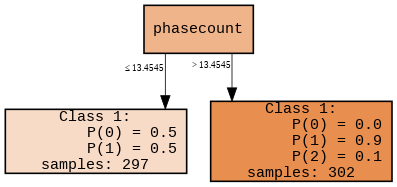


Split happened at step 1581
Current Nodes : 5



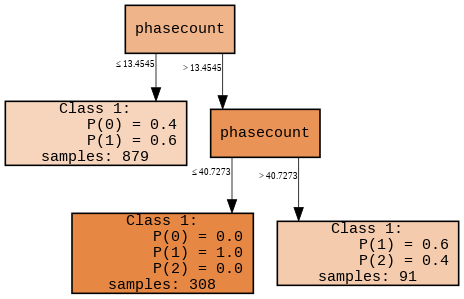


Concept Drift detected at step 2847
Total Drift : 1

Split happened at step 3063
Current Nodes : 7



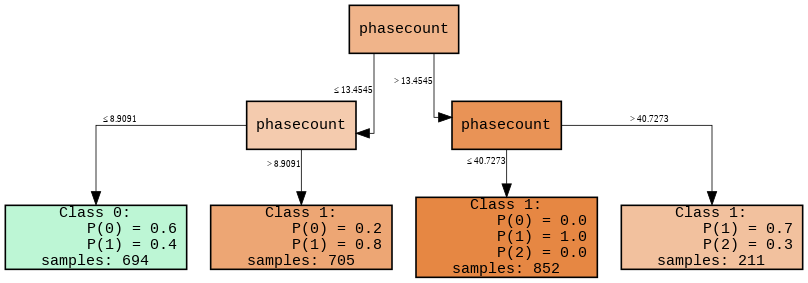


Concept Drift detected at step 10527
Total Drift : 2

Concept Drift detected at step 10943
Total Drift : 3

Concept Drift detected at step 12959
Total Drift : 4

Concept Drift detected at step 15903
Total Drift : 5

Concept Drift detected at step 17791
Total Drift : 6

Concept Drift detected at step 23103
Total Drift : 7

Split happened at step 24840
Current Nodes : 9



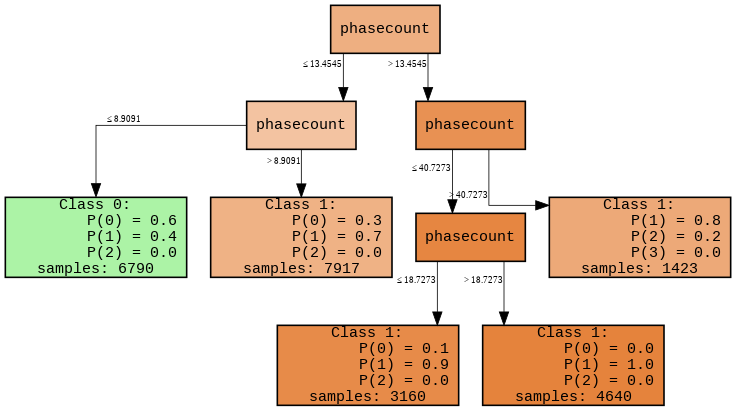


Split happened at step 25369
Current Nodes : 11



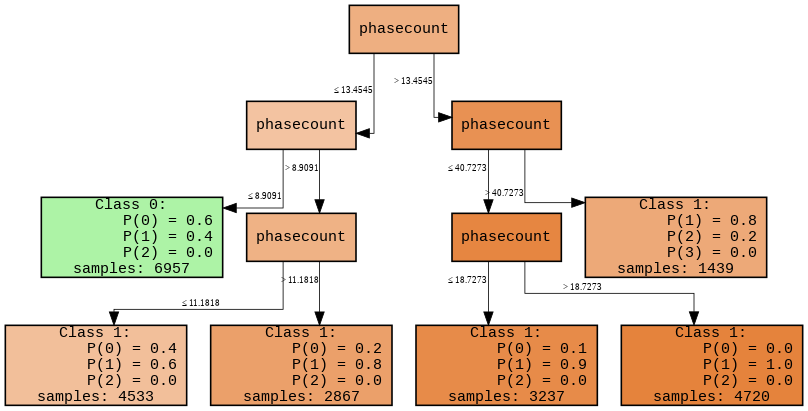


Concept Drift detected at step 25407
Total Drift : 8

Concept Drift detected at step 28543
Total Drift : 9

Split happened at step 29896
Current Nodes : 13



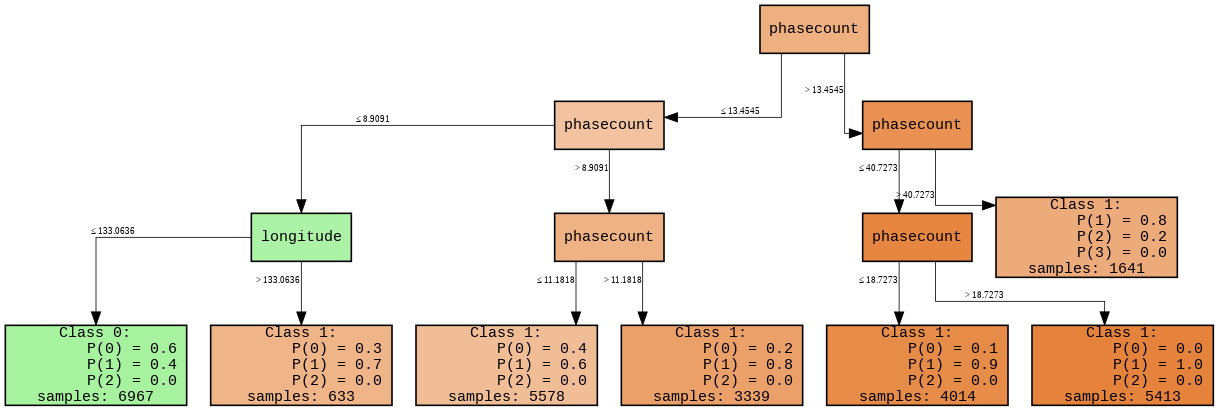


Split happened at step 35232
Current Nodes : 15



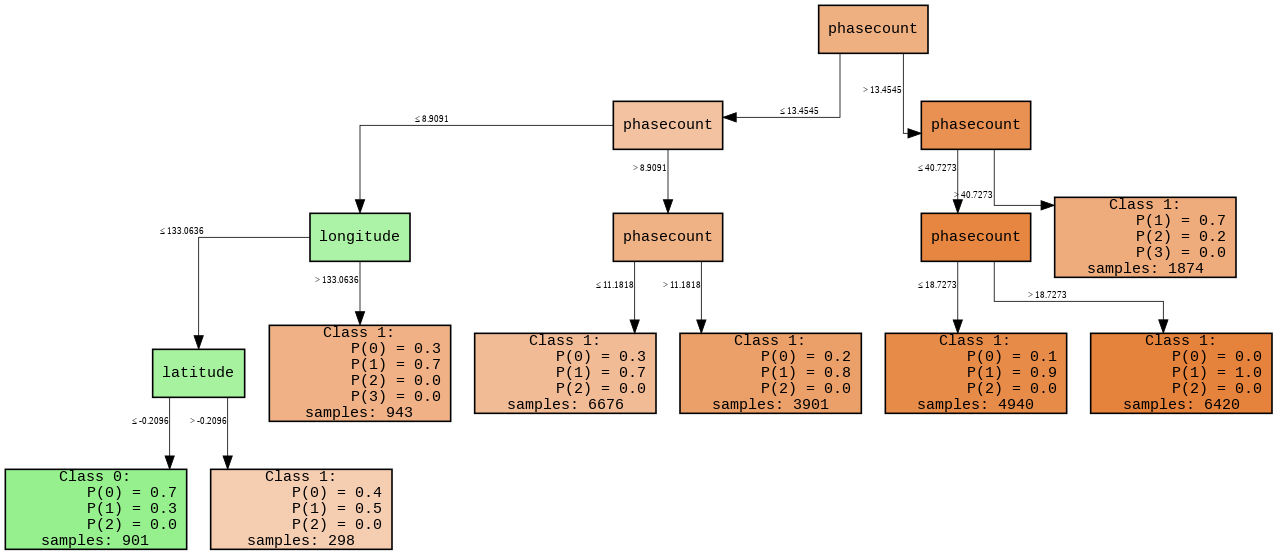


Concept Drift detected at step 35295
Total Drift : 10

Concept Drift detected at step 38303
Total Drift : 11

Concept Drift detected at step 39039
Total Drift : 12

Concept Drift detected at step 40447
Total Drift : 13

Split happened at step 42115
Current Nodes : 17



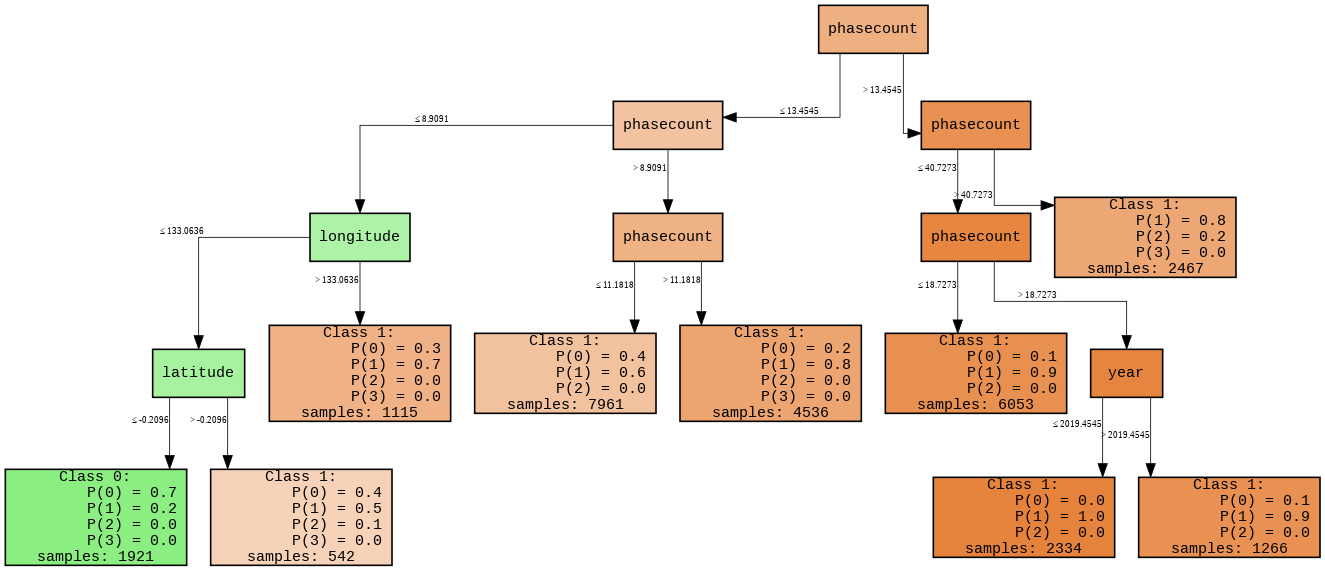


Concept Drift detected at step 42463
Total Drift : 14

Split happened at step 43267
Current Nodes : 19



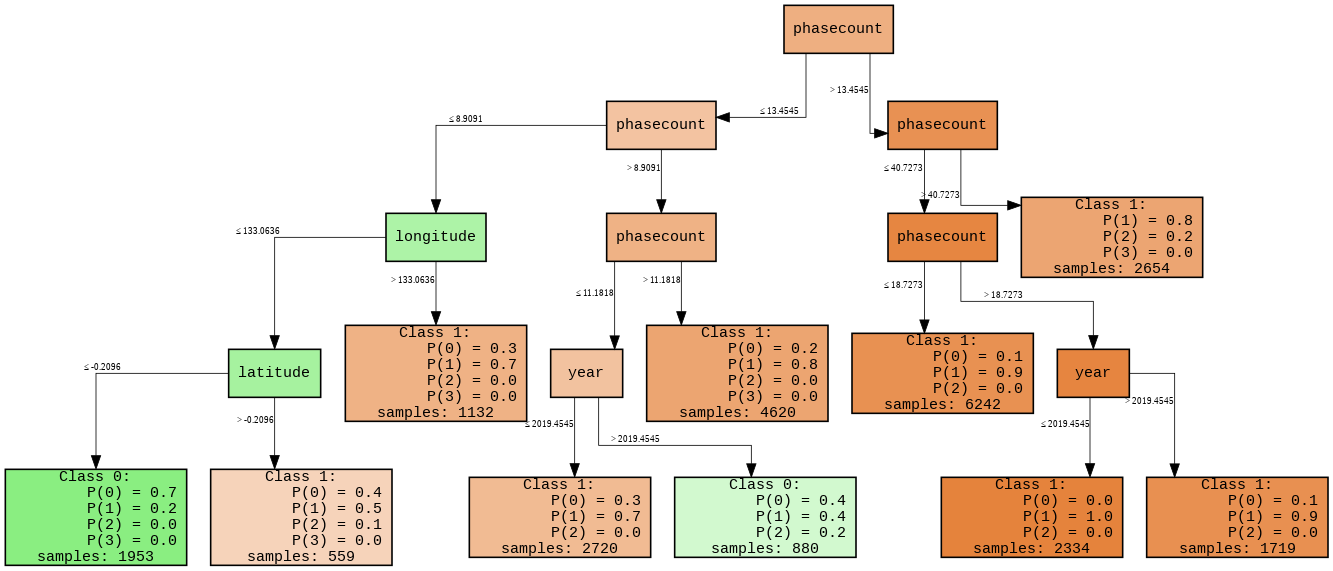


Concept Drift detected at step 47231
Total Drift : 15

Split happened at step 49980
Current Nodes : 21



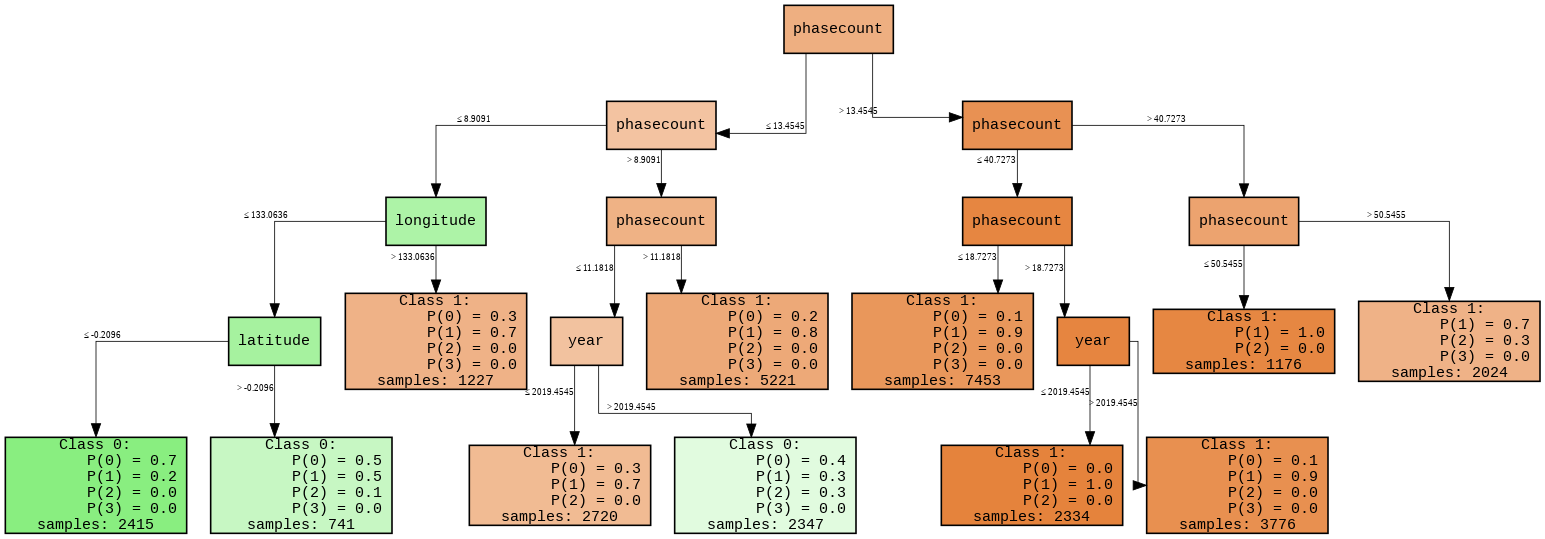


Split happened at step 53134
Current Nodes : 23



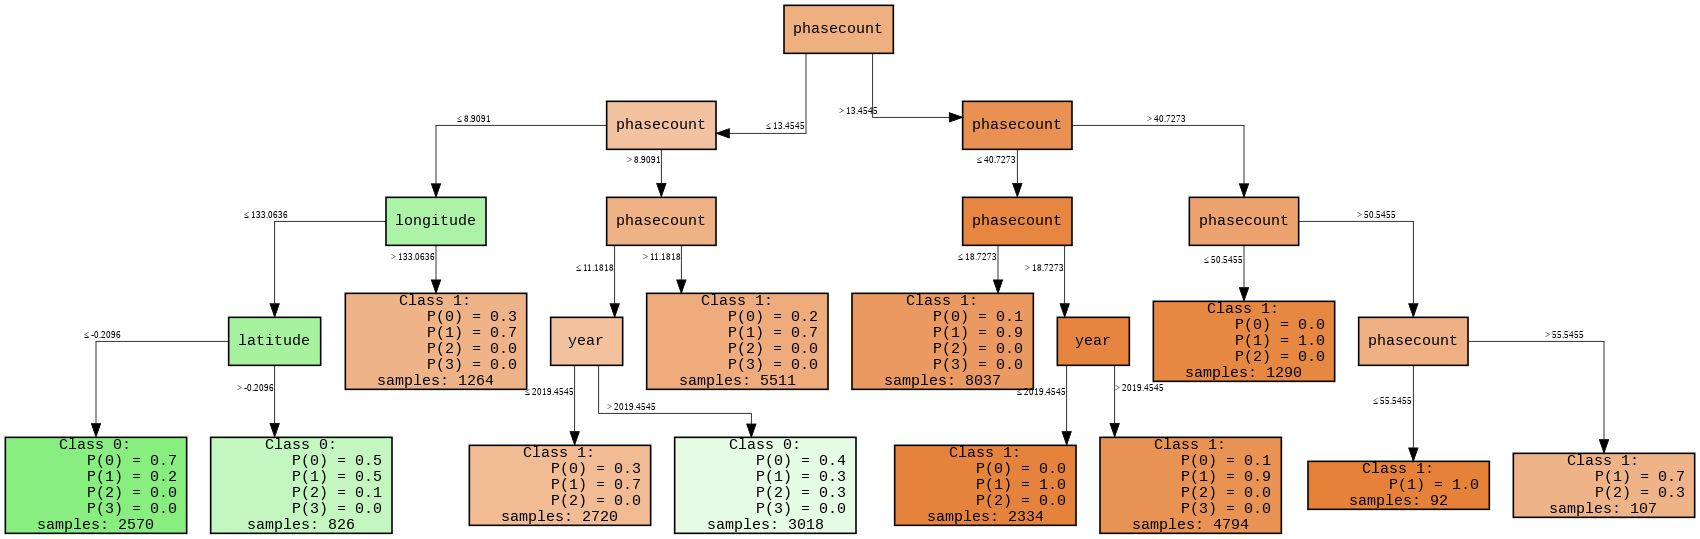


Concept Drift detected at step 53407
Total Drift : 16

Concept Drift detected at step 61791
Total Drift : 17

Concept Drift detected at step 64575
Total Drift : 18

Concept Drift detected at step 66527
Total Drift : 19

Concept Drift detected at step 69823
Total Drift : 20

Split happened at step 73087
Current Nodes : 25



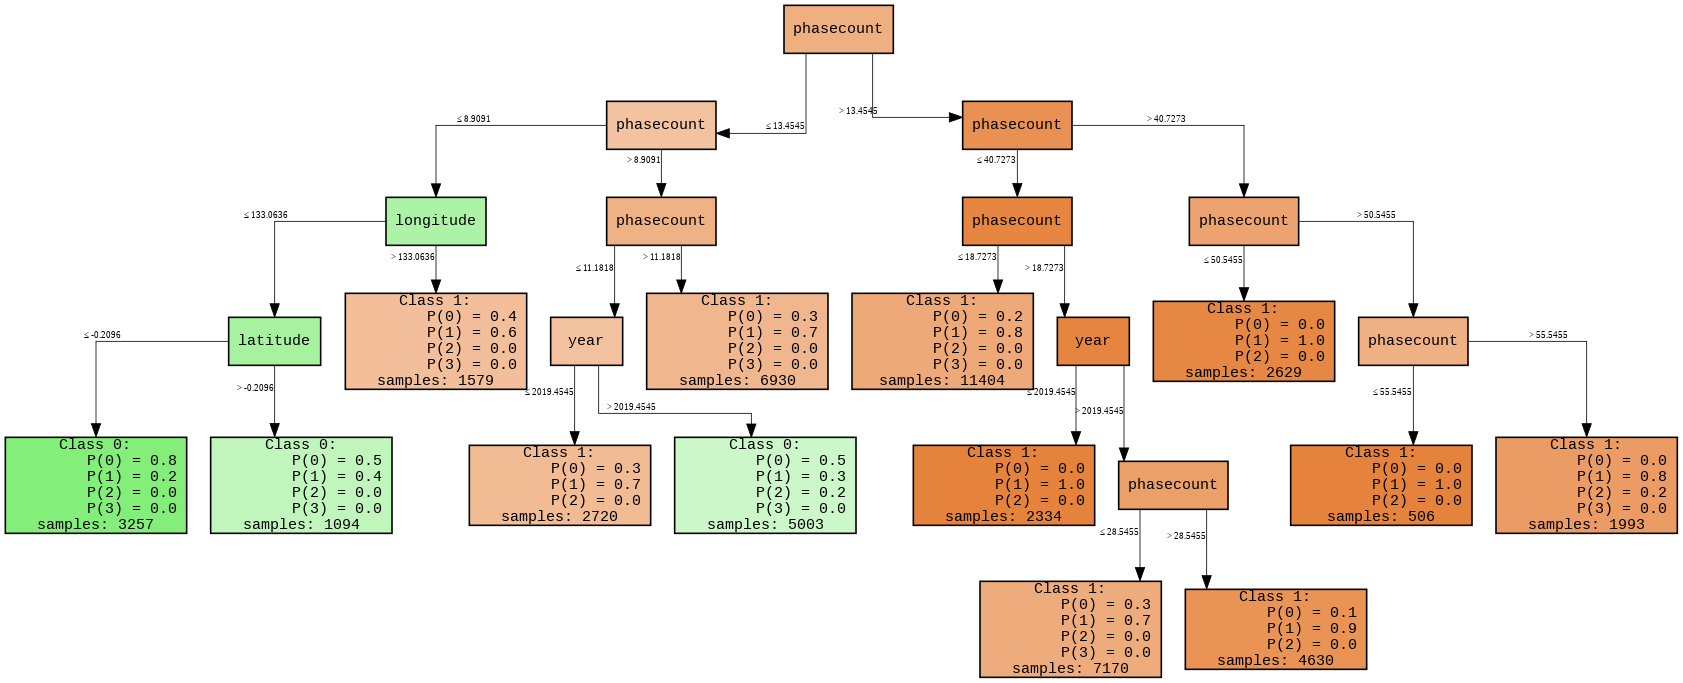


Concept Drift detected at step 77087
Total Drift : 21

Split happened at step 84181
Current Nodes : 27



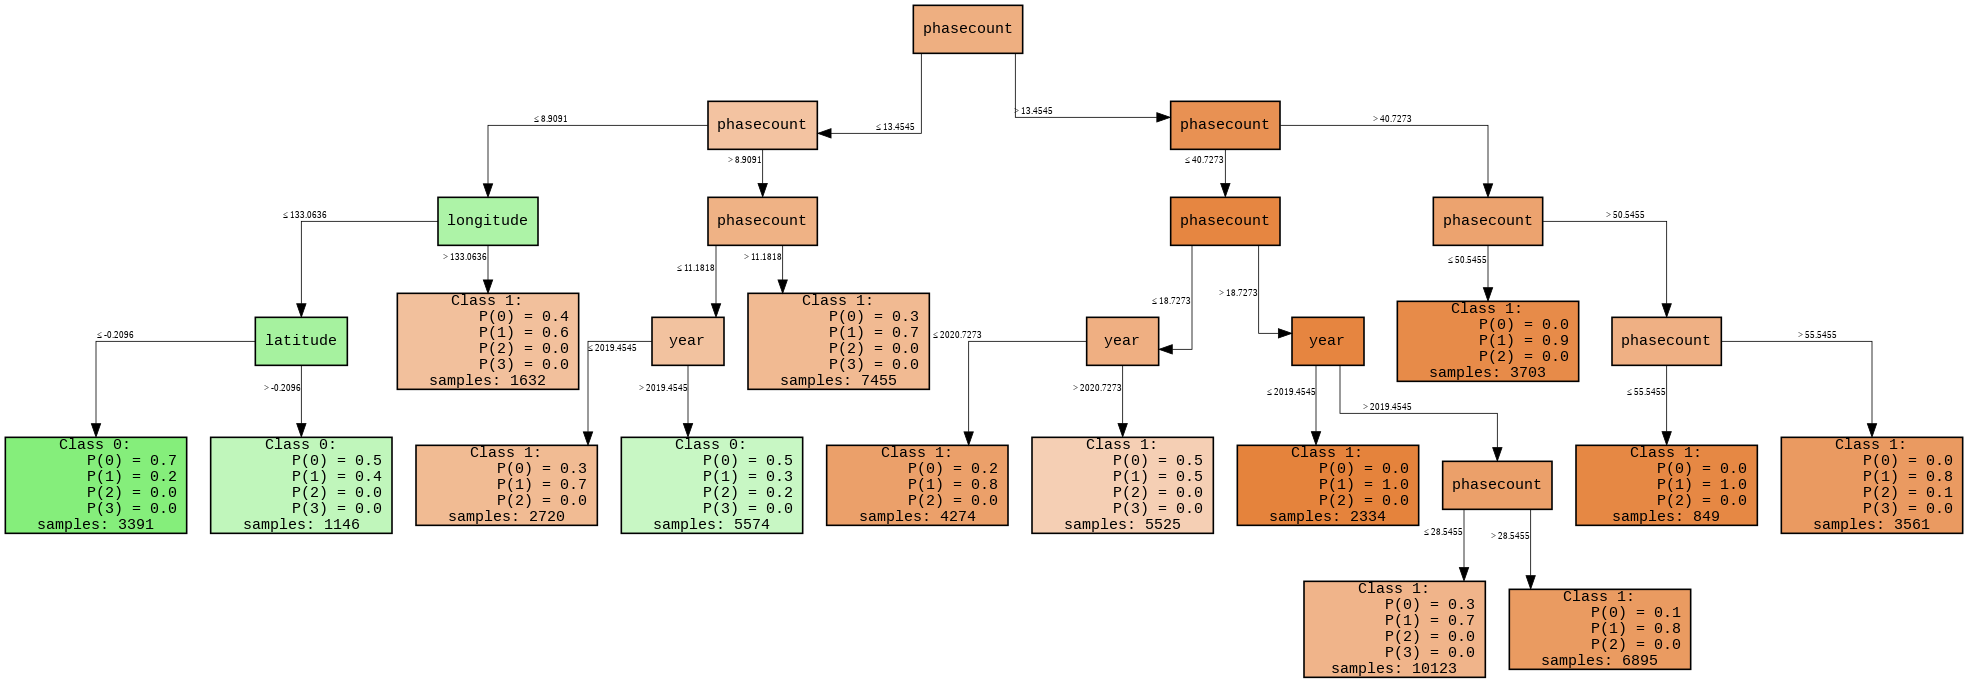


Concept Drift detected at step 84383
Total Drift : 22

Split happened at step 87881
Current Nodes : 29



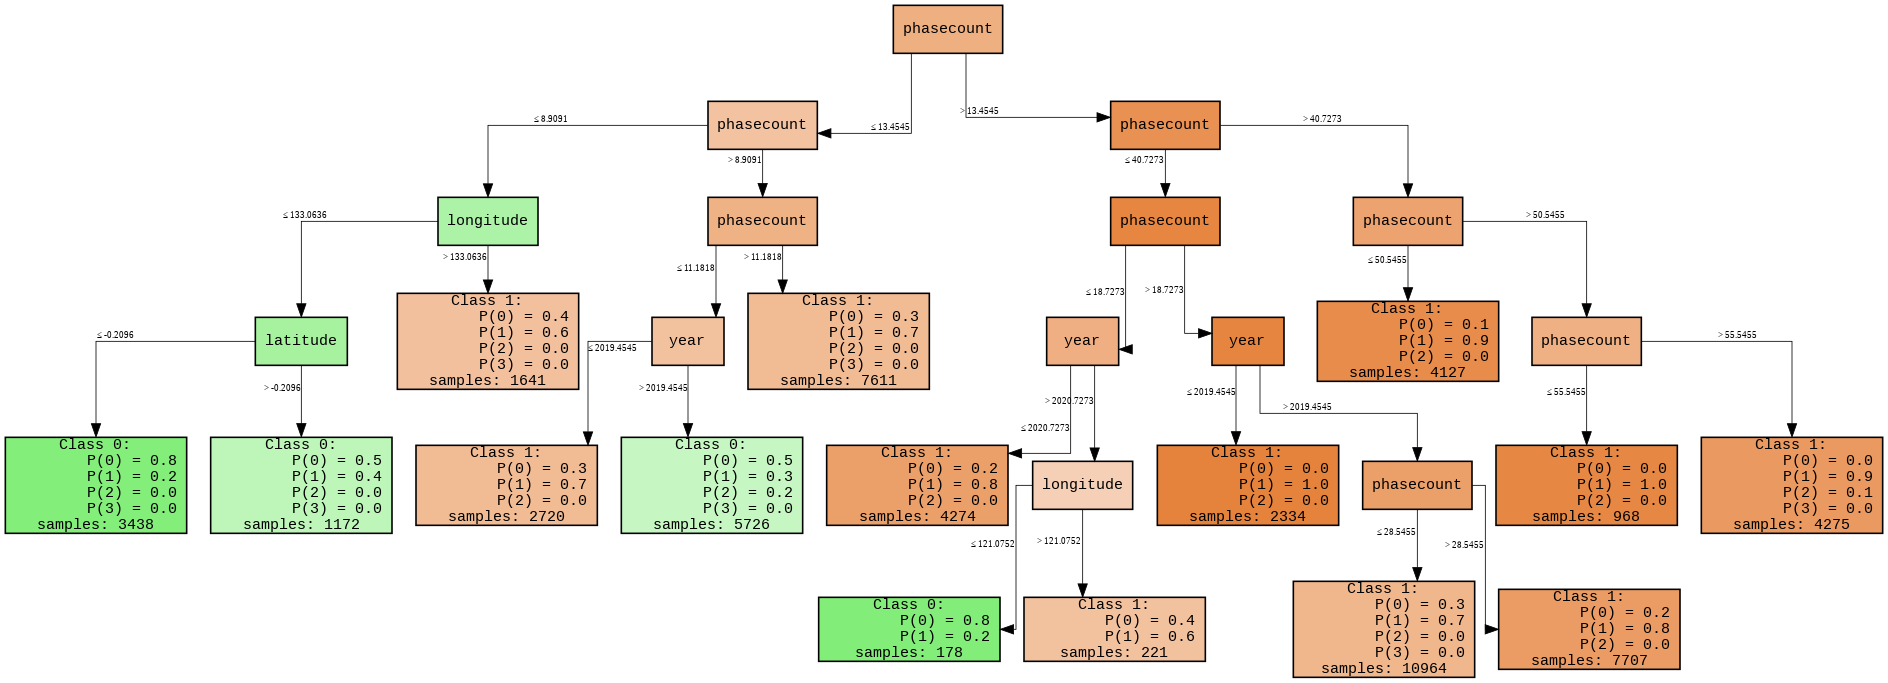


Concept Drift detected at step 88959
Total Drift : 23

Split happened at step 90315
Current Nodes : 31



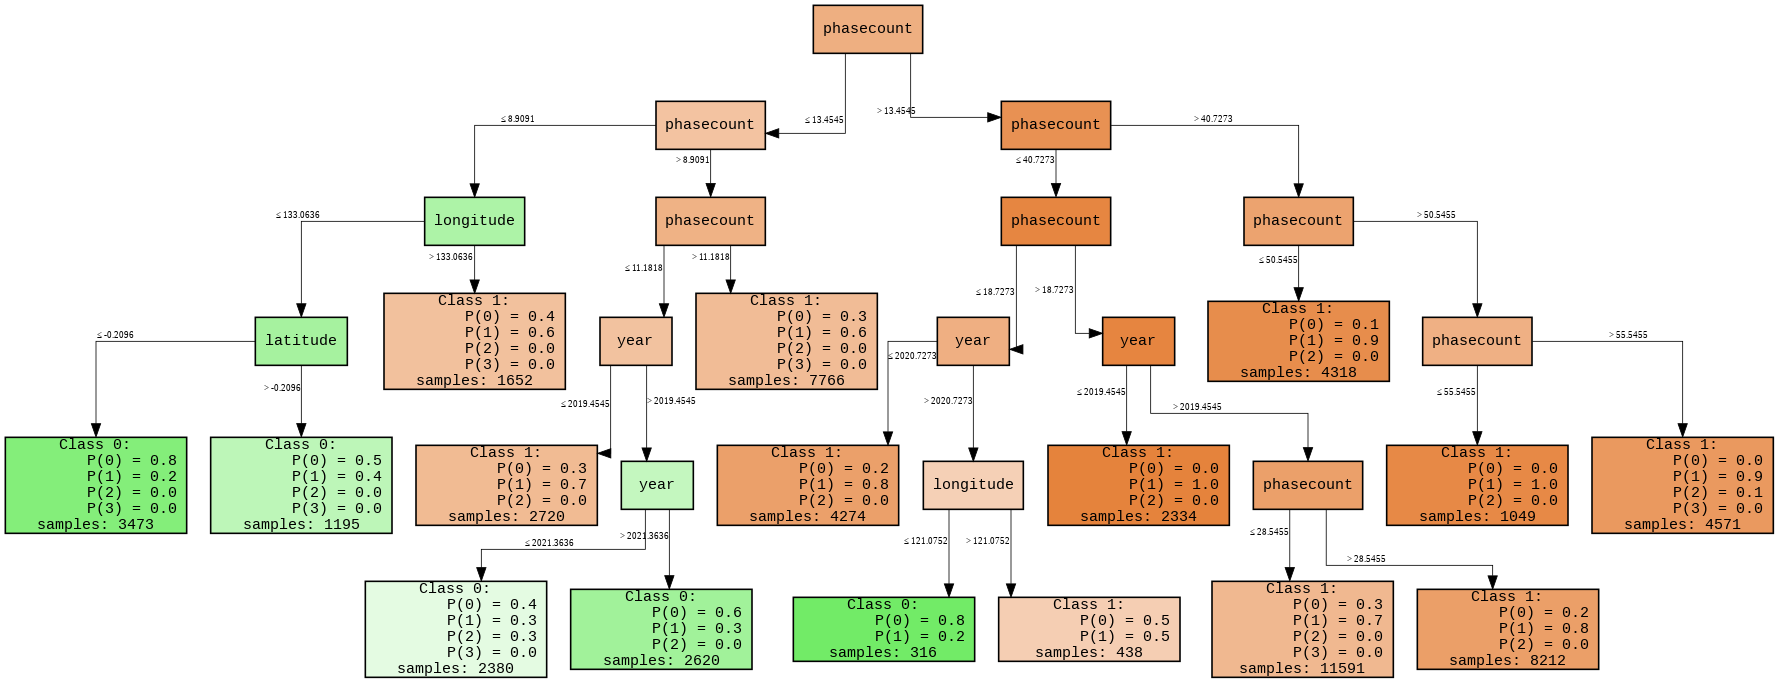


Split happened at step 90398
Current Nodes : 33



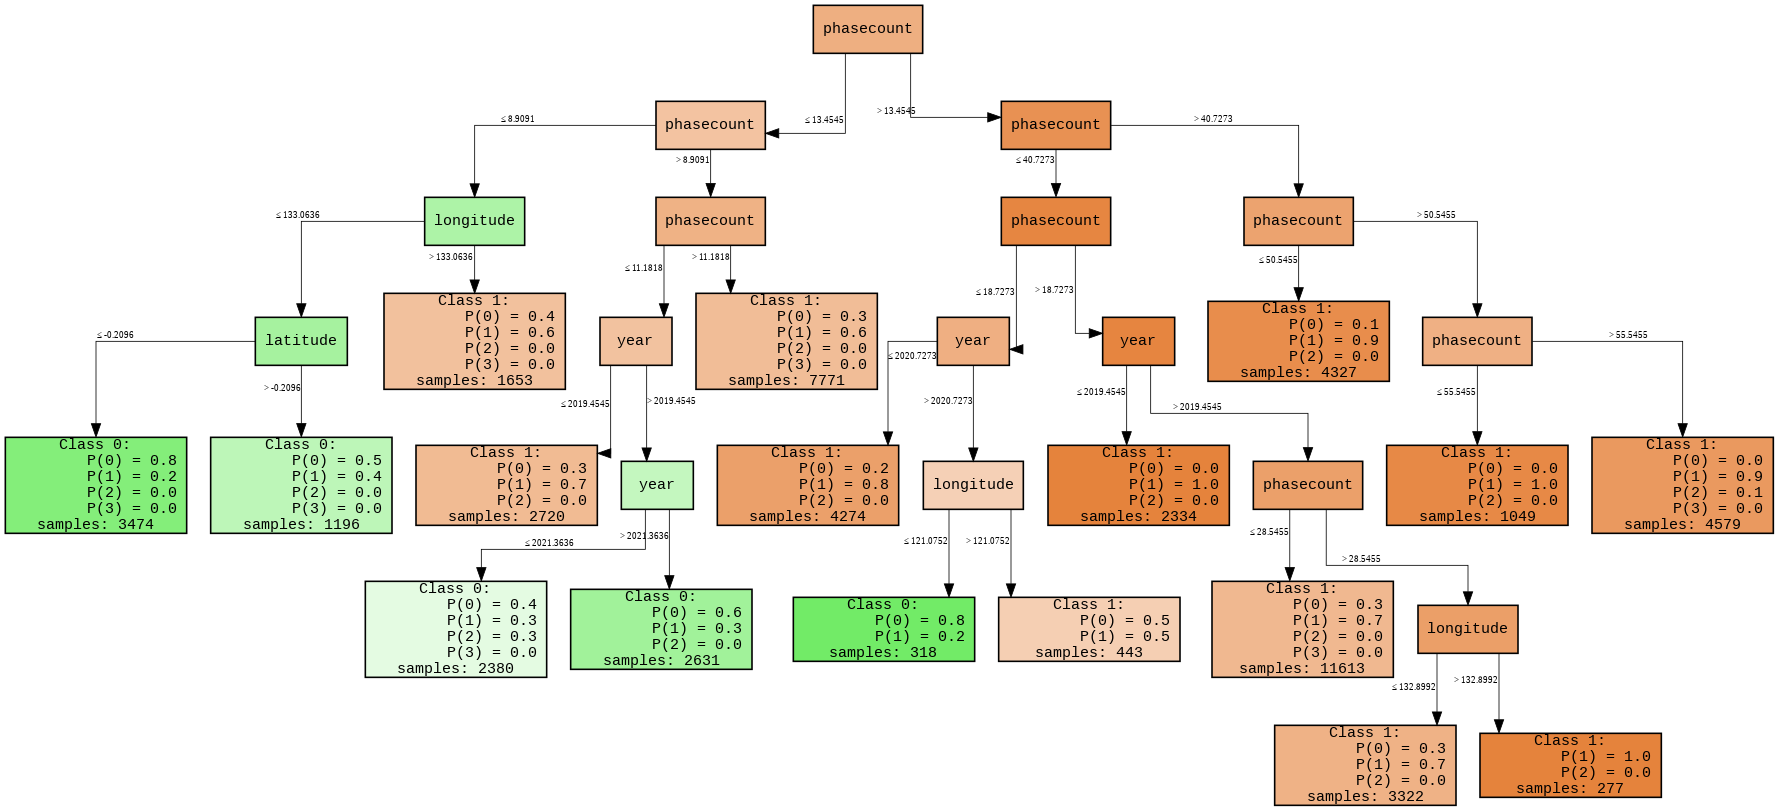


Split happened at step 95308
Current Nodes : 35



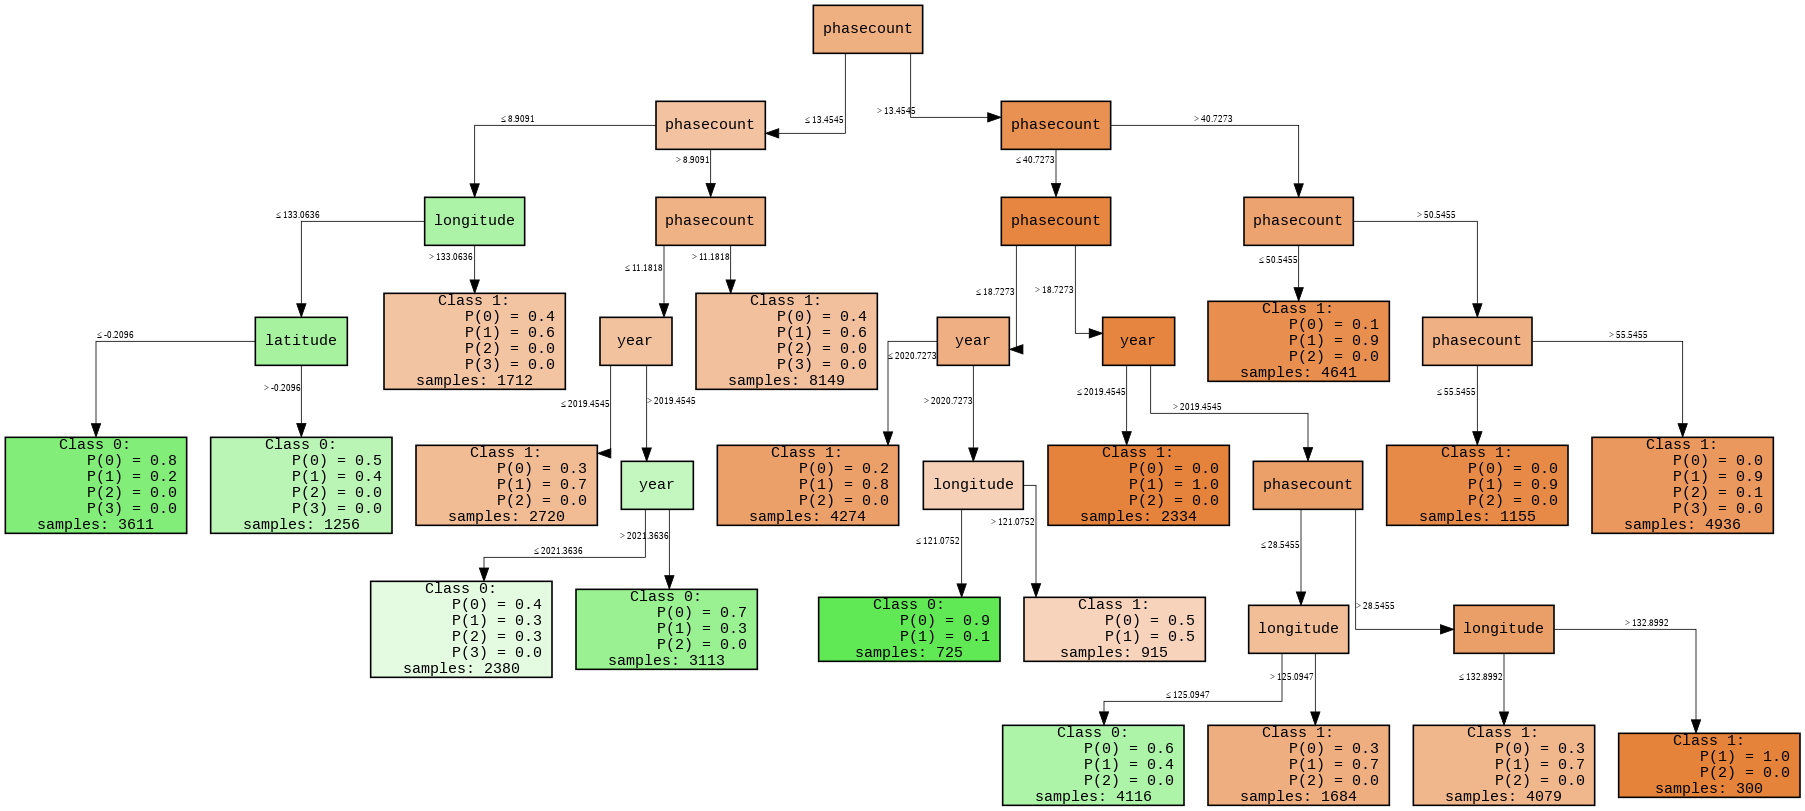


Concept Drift detected at step 95967
Total Drift : 24

Split happened at step 99249
Current Nodes : 37



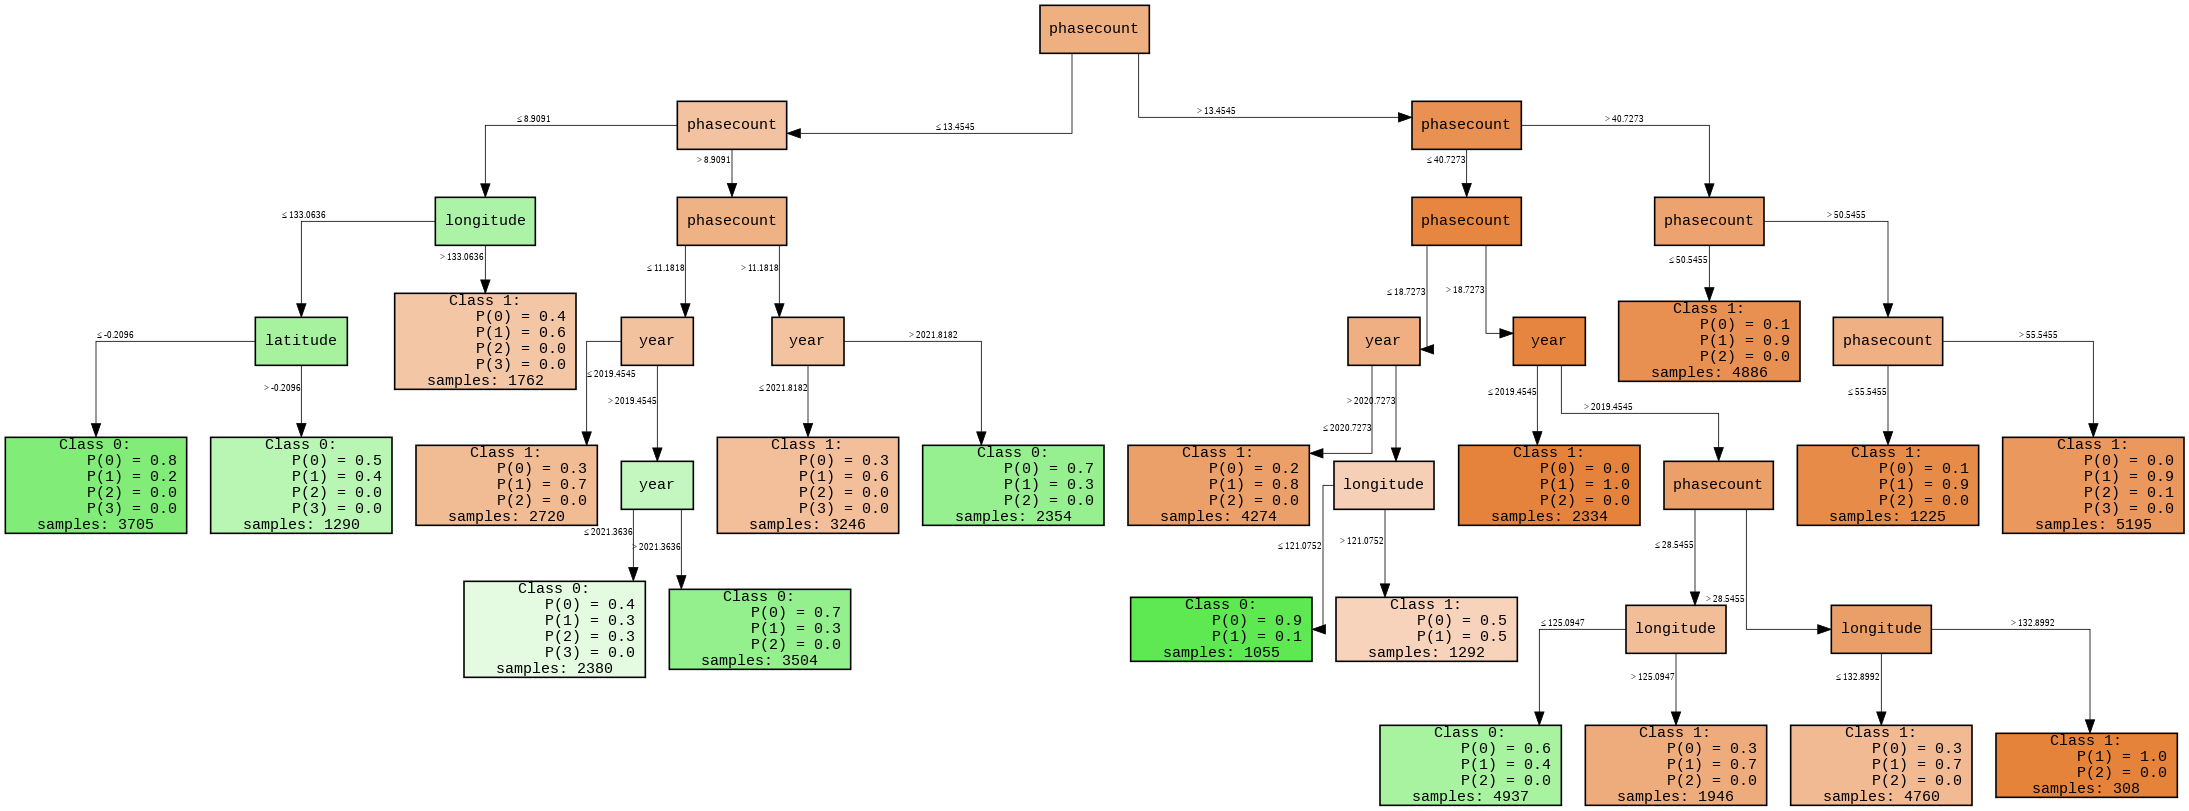


Concept Drift detected at step 99903
Total Drift : 25

Split happened at step 100654
Current Nodes : 39



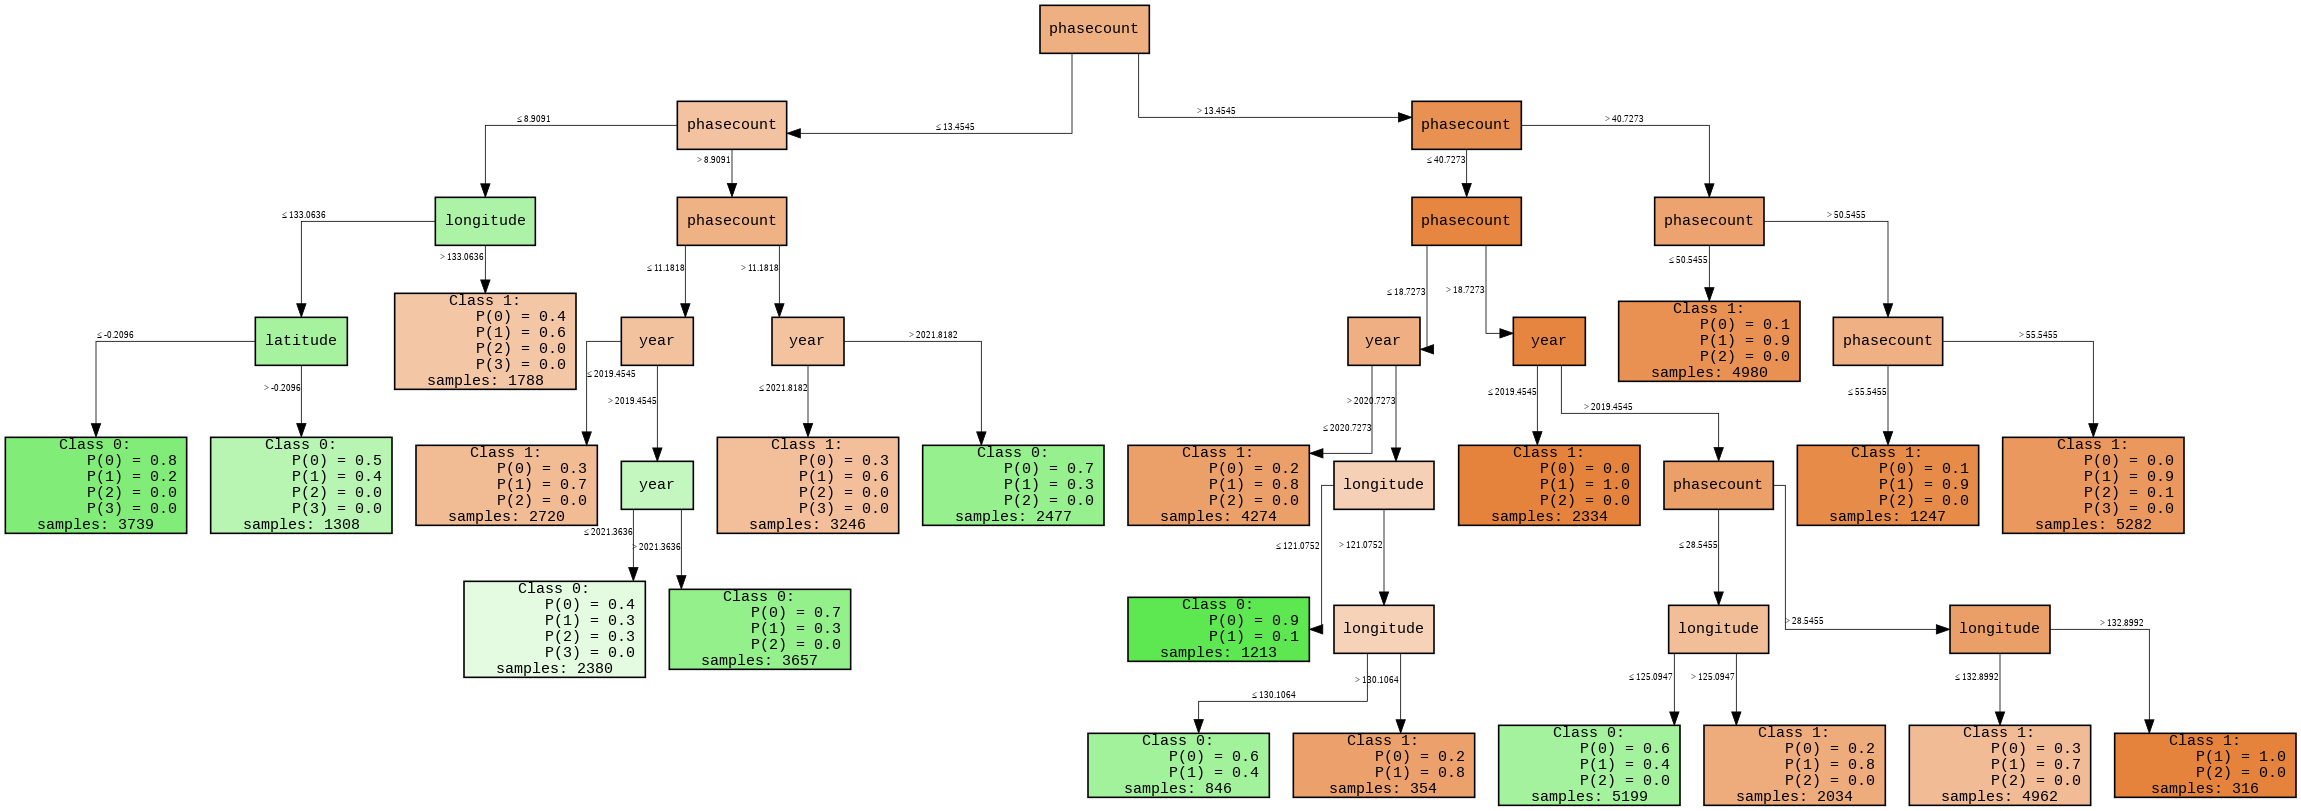


Split happened at step 101603
Current Nodes : 41



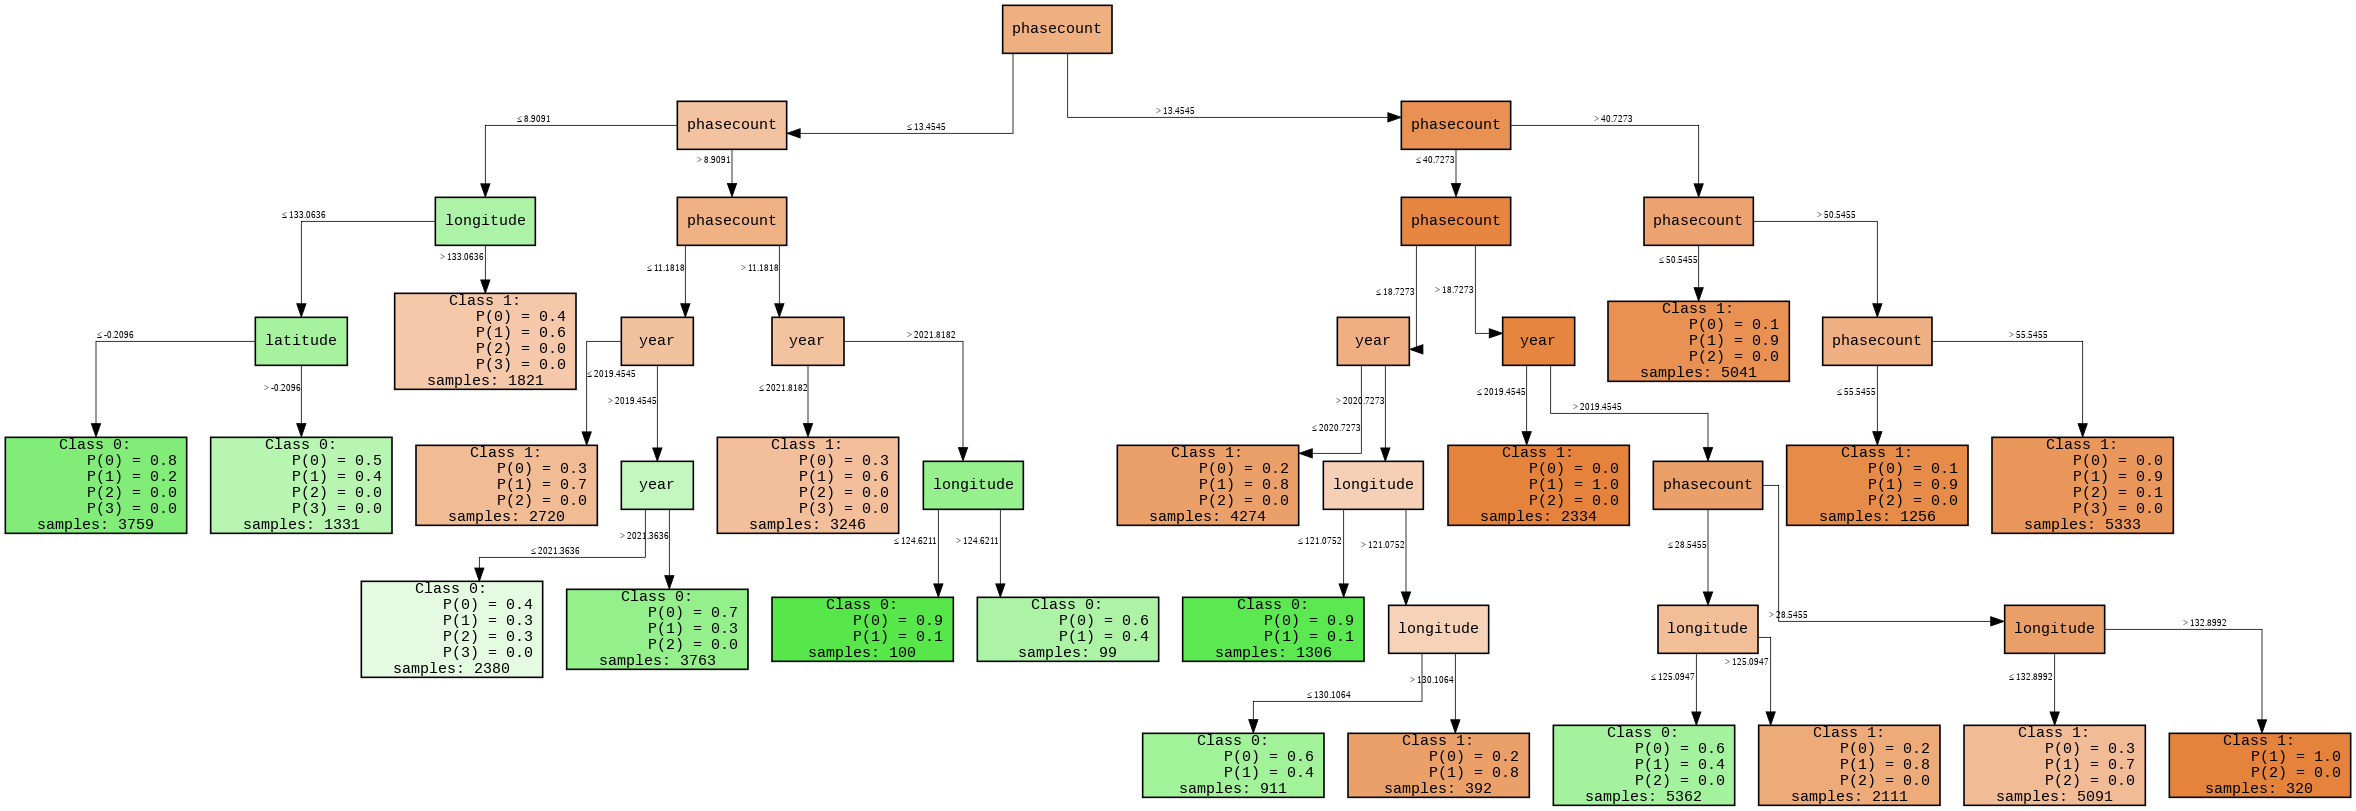

In [ ]:
start_time = time.time()
for x_i, y_i in dataset:  # ← ganti jadi x_i, y_i

    # SIMPAN PREDIKSI SEBELUM LEARN
    y_pred_display = model_ht.predict_one(x_i)

    if y_pred_display is None:
        y_pred_display = 0

    hasil_prediksi.append({
        'label_aktual'   : y_i,
        'label_prediksi' : y_pred_display,
    })

    # UPDATE MODEL
    model_ht, metric_ht = update_model_ht(x_i, y_i, t)

    # SIMPAN AKURASI HT STREAM
    akurasi_ht_list.append(metric_ht.get())
    data_ke_ht.append(t)

    # MONITOR SPLIT TREE
    current_nodes = model_ht.n_nodes

    if current_nodes > prev_nodes:
        print(f"\n===================================")
        print(f"Split happened at step {t}")
        print(f"Current Nodes : {current_nodes}")
        print("===================================\n")

        try:
            graph = model_ht.draw()
            graph.render(filename="hoeffding_tree", format="png", cleanup=True)
            display(Image("hoeffding_tree.png"))
        except Exception as e:
            print("Visualization Error :", e)

    prev_nodes = current_nodes
    t += 1
end_time = time.time()

In [ ]:
# BUAT DATAFRAME DRIFT
df_drift = pd.DataFrame(hasil_drift_log)
df_drift['tanggal'] = df_drift['step'].apply(lambda s: data.iloc[s]['datetime'])
df_drift['tahun']   = pd.to_datetime(df_drift['tanggal']).dt.year
df_drift['bulan']   = pd.to_datetime(df_drift['tanggal']).dt.month

print("\n=== LOG CONCEPT DRIFT DENGAN TANGGAL ===")
print(df_drift.to_string())

# ================================
# COCOKKAN DENGAN GEMPA BESAR
# ================================
gempa_besar = pd.DataFrame([
    {'nama': 'Gempa Pidie Jaya',  'tahun': 2016, 'bulan': 12},
    {'nama': 'Gempa Lombok 1',    'tahun': 2018, 'bulan': 7},
    {'nama': 'Gempa Lombok 2',    'tahun': 2018, 'bulan': 8},
    {'nama': 'Gempa Palu',        'tahun': 2018, 'bulan': 9},
    {'nama': 'Gempa Majene',      'tahun': 2021, 'bulan': 1},
    {'nama': 'Gempa Cianjur',     'tahun': 2022, 'bulan': 11},
])

# CARI DRIFT YANG BERDEKATAN (toleransi 3 bulan)
korelasi = []

for _, gempa in gempa_besar.iterrows():
    for _, drift_row in df_drift.iterrows():

        selisih_bulan = abs(
            (drift_row['tahun'] - gempa['tahun']) * 12 +
            (drift_row['bulan'] - gempa['bulan'])
        )

        if selisih_bulan <= 3:
            korelasi.append({
                'gempa_besar'  : gempa['nama'],
                'tahun_gempa'  : gempa['tahun'],
                'bulan_gempa'  : gempa['bulan'],
                'drift_ke'     : drift_row['drift_ke'],
                'step_drift'   : drift_row['step'],
                'tanggal_drift': drift_row['tanggal'],
                'selisih_bulan': selisih_bulan
            })

df_korelasi = pd.DataFrame(korelasi)

print("\n=== KORELASI DRIFT DENGAN GEMPA BESAR ===")
if len(df_korelasi) > 0:
    print(df_korelasi.to_string())
else:
    print("Tidak ada drift yang berdekatan dengan kejadian gempa besar.")


=== LOG CONCEPT DRIFT DENGAN TANGGAL ===
    drift_ke   step                          tanggal  tahun  bulan
0          1   2847 2015-08-07 13:05:41.581621+00:00   2015      8
1          2  10527 2016-12-07 08:08:07.307261+00:00   2016     12
2          3  10943 2017-01-04 00:28:23.322745+00:00   2017      1
3          4  12959 2017-05-07 07:25:01.519641+00:00   2017      5
4          5  15903 2017-09-23 10:22:43.672419+00:00   2017      9
5          6  17791 2017-12-15 02:18:17.886090+00:00   2017     12
6          7  23103 2018-07-30 13:13:05.513741+00:00   2018      7
7          8  25407 2018-09-28 12:01:31.556489+00:00   2018      9
8          9  28543 2019-02-03 06:51:29.674685+00:00   2019      2
9         10  35295 2019-09-26 01:20:25.677908+00:00   2019      9
10        11  38303 2019-12-09 13:15:29.281399+00:00   2019     12
11        12  39039 2020-01-12 03:30:19.376498+00:00   2020      1
12        13  40447 2020-03-11 17:13:01.331960+00:00   2020      3
13        14  42463 

In [ ]:
label_nama = {0: 'Rendah', 1: 'Sedang', 2: 'Tinggi', 3: 'Ekstrem'}

df_prediksi = pd.DataFrame(hasil_prediksi)
df_prediksi['label_aktual']   = df_prediksi['label_aktual'].map(label_nama)
df_prediksi['label_prediksi'] = df_prediksi['label_prediksi'].map(label_nama)

print("\n=== PREDIKSI TINGKAT BAHAYA PER KEJADIAN GEMPA ===")
print(df_prediksi.head(20))


=== PREDIKSI TINGKAT BAHAYA PER KEJADIAN GEMPA ===
   label_aktual label_prediksi
0        Sedang         Rendah
1        Sedang         Sedang
2        Sedang         Sedang
3        Sedang         Sedang
4        Sedang         Sedang
5        Sedang         Sedang
6        Sedang         Sedang
7        Sedang         Sedang
8        Sedang         Sedang
9        Sedang         Sedang
10       Sedang         Sedang
11       Sedang         Sedang
12       Sedang         Sedang
13       Sedang         Sedang
14       Sedang         Sedang
15       Sedang         Sedang
16       Sedang         Sedang
17       Sedang         Sedang
18       Sedang         Sedang
19       Sedang         Sedang


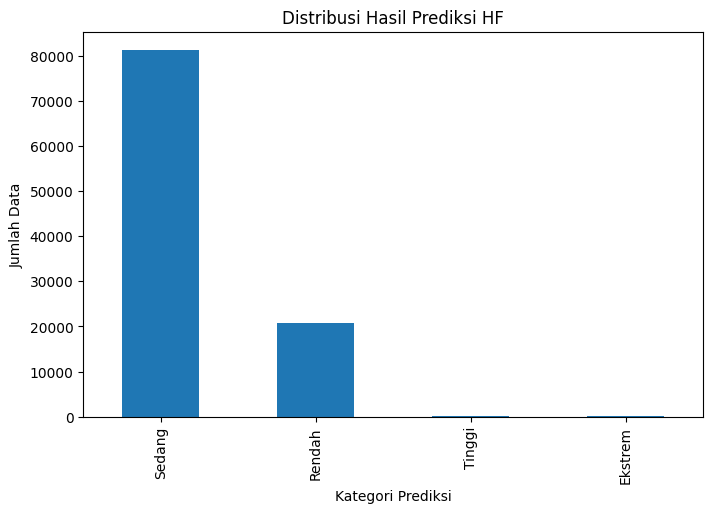

In [ ]:
plt.figure(figsize=(8,5))

df_prediksi['label_prediksi'].value_counts().plot(
    kind='bar'
)

plt.title('Distribusi Hasil Prediksi HF')
plt.xlabel('Kategori Prediksi')
plt.ylabel('Jumlah Data')

plt.show()

Evaluasi model

In [ ]:
accuracy_ht = metric_ht.get()
error_rate  = 1 - accuracy_ht

print("Final Accuracy :", round(accuracy_ht, 4))
print("Error Rate    :", round(error_rate, 4))
print("Precision      :", round(precision_ht.get(), 4))
print("Recall         :", round(recall_ht.get(), 4))
print("F1             :", round(f1_ht.get(), 4))
print("Waktu Komputasi:", round(end_time - start_time, 2), "detik")
print("Total Drift    :", drift_ht)
print("Total Step     :", t)
print("Total Nodes    :", model_ht.n_nodes)

Final Accuracy : 0.721
Error Rate    : 0.279
Precision      : 0.2964
Recall         : 0.2661
F1             : 0.2673
Waktu Komputasi: 15.3 detik
Total Drift    : 25
Total Step     : 102257
Total Nodes    : 41


Prediksi Bahaya Gempa

In [ ]:
# Ambil 30 data terakhir sebagai referensi
data_terakhir = data.tail(30)

# Buat prediksi untuk tanggal 2-4 Oktober 2025
hasil_prediksi_depan = []

for hari in range(2, 5):  # ← ubah 9 jadi 5 (2, 3, 4 Oktober)

    input_prediksi = {
        'latitude'   : data_terakhir['latitude'].mean(),
        'longitude'  : data_terakhir['longitude'].mean(),
        'depth'      : data_terakhir['depth'].mean(),
        'phasecount' : data_terakhir['phasecount'].mean(),
        'year'       : 2025,
        'month'      : 10,
        'day'        : hari,
        'hour'       : 12,
    }

    prediksi = model_ht.predict_one(input_prediksi)

    hasil_prediksi_depan.append({
        'tanggal'        : f"2025-10-{hari:02d}",  # ← fix format tanggal
        'hasil_prediksi' : label_nama[prediksi],
    })

# TAMPILKAN HASIL
df_prediksi_depan = pd.DataFrame(hasil_prediksi_depan)

print("\n=== PREDIKSI TINGKAT BAHAYA GEMPA 3 HARI KE DEPAN ===")
print("       (2 - 4 Oktober 2025)                          ")
print(df_prediksi_depan.to_string(index=False))


=== PREDIKSI TINGKAT BAHAYA GEMPA 3 HARI KE DEPAN ===
       (2 - 4 Oktober 2025)                          
   tanggal hasil_prediksi
2025-10-02         Rendah
2025-10-03         Rendah
2025-10-04         Rendah


In [ ]:
# Ambil 30 data terakhir sebagai referensi
data_terakhir = data.tail(30)

hasil_prediksi_depan = []

for hari in range(2, 5):

    input_prediksi = {
        'latitude'   : data_terakhir['latitude'].mean(),
        'longitude'  : data_terakhir['longitude'].mean(),
        'depth'      : data_terakhir['depth'].mean(),
        'phasecount' : data_terakhir['phasecount'].mean(),
        'year'       : 2025,
        'month'      : 10,
        'day'        : hari,
        'hour'       : 12,
    }

    # PREDIKSI KELAS
    prediksi = model_ht.predict_one(input_prediksi)

    # PROBABILITAS TIAP KELAS
    proba = model_ht.predict_proba_one(input_prediksi)

    hasil_prediksi_depan.append({
        'tanggal'          : f"2025-10-{hari:02d}",
        'hasil_prediksi'   : label_nama[prediksi],
        'prob_rendah (%)'  : round(proba.get(0, 0) * 100, 2),
        'prob_sedang (%)'  : round(proba.get(1, 0) * 100, 2),
        'prob_tinggi (%)'  : round(proba.get(2, 0) * 100, 2),
        'prob_ekstrem (%)' : round(proba.get(3, 0) * 100, 2),
    })

df_prediksi_depan = pd.DataFrame(hasil_prediksi_depan)

print("\n=== PREDIKSI TINGKAT BAHAYA GEMPA 3 HARI KE DEPAN (HT) ===")
print("              (2 - 4 Oktober 2025)                         ")
print(df_prediksi_depan.to_string(index=False))


=== PREDIKSI TINGKAT BAHAYA GEMPA 3 HARI KE DEPAN (HT) ===
              (2 - 4 Oktober 2025)                         
   tanggal hasil_prediksi  prob_rendah (%)  prob_sedang (%)  prob_tinggi (%)  prob_ekstrem (%)
2025-10-02         Rendah            91.34             8.66              0.0               0.0
2025-10-03         Rendah            91.34             8.66              0.0               0.0
2025-10-04         Rendah            91.34             8.66              0.0               0.0


Pada hasil modelling diatas terlihat bahwa model berhasil memprediksi tingkat bahaya gempa sebesar 72,1%. Selain itu, ADWIN mendeteksi perubahan pola sebesar 25 kali dari total data 102257 dan model berhasil berkembang dengan melakukan split pada tree sebanyak 41 nodes sehingga model memang belajar pola data.

## **ARF (Adaptive Random Forest)**

Adaptive Random Forest (ARF) merupakan metode ensemble berbasis stream mining yang dikembangkan dari Hoeffding Tree. Model ini bekerja dengan membangun beberapa pohon keputusan yang dilatih secara paralel menggunakan teknik online-bagging dan random feature selection.

Pada penelitian ini dilakukan pengujian parameter untuk mengetahui konfigurasi terbaik dalam klasifikasi tingkat bahaya gempa bumi. Parameter yang diuji meliputi (`n_models`), (`max_features`) dan (`delta`) yang digunakan pada setiap tree.

Inisialisasi Model Adaptive Random Forest

In [ ]:
y_stream = data['label']

#mengubah ke dalam bentuk data  stream
stream_arf = stream.iter_pandas(X, y_stream)

#model ARF
model_arf = forest.ARFClassifier(n_models=20, max_features=1.0, delta=0.1, seed=42)

#metrik Evaluasi
metric_arf = metrics.Accuracy()
precision_arf = metrics.MacroPrecision()
recall_arf    = metrics.MacroRecall()
f1_arf        = metrics.MacroF1()

#inisialisasi concept drift mengggunakan ADWIN
adwin_arf = drift.ADWIN()

Inisialisasi variabel monitoring

In [ ]:
t = 0
drift_arf = 0

akurasi_list = []
data_ke = []
titik_drift = []

hasil_prediksi_arf = []

print(model_arf)
print("Initial Accuracy :", metric_arf.get())

ARFClassifier
Initial Accuracy : 0.0


Update Model ARF ke tahap prediksi

In [ ]:
def update_model_arf(x, y):

    global model_arf
    global drift_arf

    # prediksi
    y_pred = model_arf.predict_one(x)

    # jika prediksi awal None
    if y_pred is None:
        y_pred = 0

    # update metrik
    metric_arf.update(y, y_pred)
    precision_arf.update(y, y_pred)
    recall_arf.update(y, y_pred)
    f1_arf.update(y, y_pred)

    # hitung error
    error = 0 if y_pred == y else 1

    # update adwin
    adwin_arf.update(error)

    # cek concept drift
    if adwin_arf.drift_detected:

        drift_arf += 1
        titik_drift.append(t)

    # model belajar
    model_arf.learn_one(x, y)

    return y_pred

Proses Streaming menggunakan model ARF

In [ ]:
start_arf = time.time()

for x, y_true in stream_arf:

    # update model
    y_pred = update_model_arf(x, y_true)

    # simpan hasil prediksi
    hasil_prediksi_arf.append({

        'label_aktual'   : y_true,
        'label_prediksi' : y_pred

    })

    # simpa akurasi stream
    akurasi_list.append(metric_arf.get())
    data_ke.append(t)

    # progress setiap 10000 data
    if (t + 1) % 10000 == 0:

        print(f"\nData ke-{t+1}")
        print(f"Akurasi sementara : {metric_arf.get():.4f}")
        print(f"Total Drift       : {drift_arf}")

    t += 1


Data ke-10000
Akurasi sementara : 0.8340
Total Drift       : 0

Data ke-20000
Akurasi sementara : 0.8376
Total Drift       : 1

Data ke-30000
Akurasi sementara : 0.8304
Total Drift       : 3

Data ke-40000
Akurasi sementara : 0.8285
Total Drift       : 5

Data ke-50000
Akurasi sementara : 0.8179
Total Drift       : 5

Data ke-60000
Akurasi sementara : 0.8140
Total Drift       : 5

Data ke-70000
Akurasi sementara : 0.8147
Total Drift       : 6

Data ke-80000
Akurasi sementara : 0.8143
Total Drift       : 7

Data ke-90000
Akurasi sementara : 0.8157
Total Drift       : 7

Data ke-100000
Akurasi sementara : 0.8180
Total Drift       : 7


Perhitungan waktu komputasi model

In [ ]:
end_arf = time.time()

waktu_arf = end_arf - start_arf

Hasil Aktual vs Prediksi

In [ ]:
label_nama = {0: 'Rendah', 1: 'Sedang', 2: 'Tinggi', 3: 'Ekstrem'}

df_prediksi_arf = pd.DataFrame(hasil_prediksi_arf)

df_prediksi_arf['label_aktual'] = (
        df_prediksi_arf['label_aktual']
        .astype(int)
        .map(label_nama)
    )

df_prediksi_arf['label_prediksi'] = (
        df_prediksi_arf['label_prediksi']
        .astype(int)
        .map(label_nama)
    )

print("\n=== PREDIKSI TINGKAT BAHAYA GEMPA (ARF) ===")

print(df_prediksi_arf.head(20))


=== PREDIKSI TINGKAT BAHAYA GEMPA (ARF) ===
   label_aktual label_prediksi
0        Sedang         Rendah
1        Sedang         Sedang
2        Sedang         Sedang
3        Sedang         Sedang
4        Sedang         Sedang
5        Sedang         Sedang
6        Sedang         Sedang
7        Sedang         Sedang
8        Sedang         Sedang
9        Sedang         Sedang
10       Sedang         Sedang
11       Sedang         Sedang
12       Sedang         Sedang
13       Sedang         Sedang
14       Sedang         Sedang
15       Sedang         Sedang
16       Sedang         Sedang
17       Sedang         Sedang
18       Sedang         Sedang
19       Sedang         Sedang


Visualisasi Distribusi Hasil Prediksi ARF

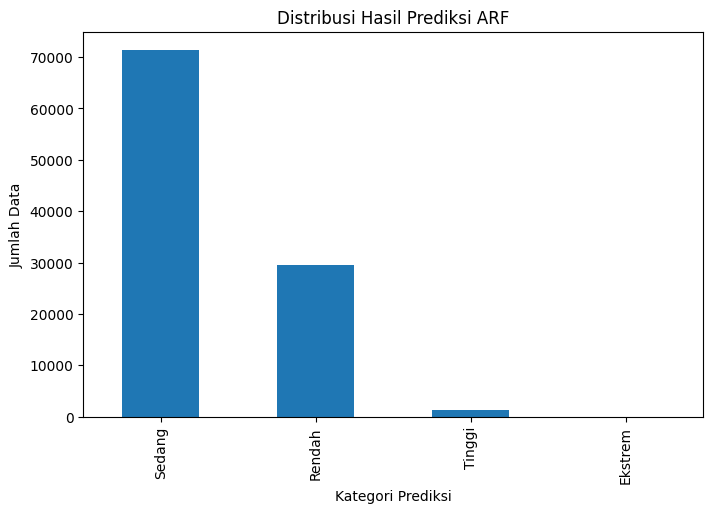

In [ ]:
plt.figure(figsize=(8,5))

df_prediksi_arf['label_prediksi'].value_counts().plot(
    kind='bar'
)

plt.title('Distribusi Hasil Prediksi ARF')
plt.xlabel('Kategori Prediksi')
plt.ylabel('Jumlah Data')

plt.show()

Log Drift Adaptive Random Forest

In [ ]:
# Buat dataframe dari titik drift ARF
hasil_drift_log_arf = []

for titik in titik_drift:
    hasil_drift_log_arf.append({
        'drift_ke' : titik_drift.index(titik) + 1,
        'step'     : titik,
    })

df_drift_arf = pd.DataFrame(hasil_drift_log_arf)
df_drift_arf['tanggal'] = df_drift_arf['step'].apply(lambda s: data.iloc[s]['datetime'])
df_drift_arf['tahun']   = pd.to_datetime(df_drift_arf['tanggal']).dt.year
df_drift_arf['bulan']   = pd.to_datetime(df_drift_arf['tanggal']).dt.month

print("\n=== LOG CONCEPT DRIFT ARF DENGAN TANGGAL ===")
print(df_drift_arf.to_string())

gempa_besar = pd.DataFrame([
    {'nama': 'Gempa Pidie Jaya',  'tahun': 2016, 'bulan': 12},
    {'nama': 'Gempa Lombok 1',    'tahun': 2018, 'bulan': 7},
    {'nama': 'Gempa Lombok 2',    'tahun': 2018, 'bulan': 8},
    {'nama': 'Gempa Palu',        'tahun': 2018, 'bulan': 9},
    {'nama': 'Gempa Majene',      'tahun': 2021, 'bulan': 1},
    {'nama': 'Gempa Cianjur',     'tahun': 2022, 'bulan': 11},
])

korelasi_arf = []

for _, gempa in gempa_besar.iterrows():
    for _, drift_row in df_drift_arf.iterrows():

        selisih_bulan = abs(
            (drift_row['tahun'] - gempa['tahun']) * 12 +
            (drift_row['bulan'] - gempa['bulan'])
        )

        if selisih_bulan <= 3:
            korelasi_arf.append({
                'gempa_besar'  : gempa['nama'],
                'tahun_gempa'  : gempa['tahun'],
                'bulan_gempa'  : gempa['bulan'],
                'drift_ke'     : drift_row['drift_ke'],
                'step_drift'   : drift_row['step'],
                'tanggal_drift': drift_row['tanggal'],
                'selisih_bulan': selisih_bulan
            })

df_korelasi_arf = pd.DataFrame(korelasi_arf)

print("\n=== KORELASI DRIFT ARF DENGAN GEMPA BESAR ===")
if len(df_korelasi_arf) > 0:
    print(df_korelasi_arf.to_string())
else:
    print("Tidak ada drift yang berdekatan dengan kejadian gempa besar.")


=== LOG CONCEPT DRIFT ARF DENGAN TANGGAL ===
   drift_ke   step                          tanggal  tahun  bulan
0         1  19615 2018-03-04 02:42:02.923915+00:00   2018      3
1         2  23615 2018-08-08 06:51:38.873870+00:00   2018      8
2         3  25631 2018-09-30 13:38:09.998647+00:00   2018      9
3         4  33503 2019-07-12 15:31:47.769886+00:00   2019      7
4         5  38527 2019-12-16 18:00:56.233683+00:00   2019     12
5         6  60479 2022-02-08 00:24:11.582132+00:00   2022      2
6         7  73439 2023-04-17 00:01:04.267103+00:00   2023      4

=== KORELASI DRIFT ARF DENGAN GEMPA BESAR ===
      gempa_besar  tahun_gempa  bulan_gempa  drift_ke  step_drift                    tanggal_drift  selisih_bulan
0  Gempa Lombok 1         2018            7         2       23615 2018-08-08 06:51:38.873870+00:00              1
1  Gempa Lombok 1         2018            7         3       25631 2018-09-30 13:38:09.998647+00:00              2
2  Gempa Lombok 2         2018       

Metrik Evaluasi Model ARF

In [ ]:
print("Final Accuracy :", metric_arf.get())
print("Final Precision:", precision_arf.get())
print("Final Recall   :", recall_arf.get())
print("Final F1       :", f1_arf.get())
print("Total Drift    :", drift_arf)
print("Total Step     :", t)
print("Jumlah Tree    :", model_arf.n_models)
print("Waktu Komputasi ARF :", waktu_arf, "detik")

Final Accuracy : 0.8183400647388442
Final Precision: 0.5667455701811095
Final Recall   : 0.47369610804847084
Final F1       : 0.5027162925028555
Total Drift    : 7
Total Step     : 102257
Jumlah Tree    : 20
Waktu Komputasi ARF : 841.8755941390991 detik


In [ ]:
# Ambil 30 data terakhir sebagai referensi
data_terakhir = data.tail(30)

hasil_prediksi_depan = []

for hari in range(2, 5):

    input_prediksi = {
        'latitude'   : data_terakhir['latitude'].mean(),
        'longitude'  : data_terakhir['longitude'].mean(),
        'depth'      : data_terakhir['depth'].mean(),
        'phasecount' : data_terakhir['phasecount'].mean(),
        'year'       : 2025,
        'month'      : 10,
        'day'        : hari,
        'hour'       : 12,
    }

    # PREDIKSI KELAS
    prediksi = model_arf.predict_one(input_prediksi)

    # PROBABILITAS TIAP KELAS
    proba = model_arf.predict_proba_one(input_prediksi)

    hasil_prediksi_depan.append({
        'tanggal'          : f"2025-10-{hari:02d}",
        'hasil_prediksi'   : label_nama[prediksi],
        'prob_rendah (%)'  : round(proba.get(0, 0) * 100, 2),
        'prob_sedang (%)'  : round(proba.get(1, 0) * 100, 2),
        'prob_tinggi (%)'  : round(proba.get(2, 0) * 100, 2),
        'prob_ekstrem (%)' : round(proba.get(3, 0) * 100, 2),
    })

df_prediksi_depan = pd.DataFrame(hasil_prediksi_depan)

print("\n=== PREDIKSI TINGKAT BAHAYA GEMPA 3 HARI KE DEPAN (ARF) ===")
print("              (2 - 4 Oktober 2025)                         ")
print(df_prediksi_depan.to_string(index=False))


=== PREDIKSI TINGKAT BAHAYA GEMPA 3 HARI KE DEPAN (HT) ===
              (2 - 4 Oktober 2025)                         
   tanggal hasil_prediksi  prob_rendah (%)  prob_sedang (%)  prob_tinggi (%)  prob_ekstrem (%)
2025-10-02         Rendah            79.07            20.93              0.0               0.0
2025-10-03         Rendah            79.07            20.93              0.0               0.0
2025-10-04         Rendah            79.07            20.93              0.0               0.0


Prediksi Bahaya menggunakan Model ARF

Pada hasil modelling diatas terlihat bahwa model  Adaptive Random Forest (ARF) berhasil memprediksi tingkat bahaya gempa sebesar 81,83%. Selain itu, ADWIN mendeteksi perubahan pola sebesar 7 kali dari total data 102257. Dengan model membangun 20 decision tree sehingga meningkarkan akurasi prediksi dan pola data.

# **Perbandingan Performa Hoeffding Tree dan Adaptive Random Forest**

## TABEL PERBANDINGAN PERFORMA MODEL

In [ ]:
hasil_perbandingan = pd.DataFrame({

    'Model': [
        'Hoeffding Tree',
        'Adaptive Random Forest'
    ],

    'Accuracy': [
        round(metric_ht.get(), 2),
        round(metric_arf.get(), 2)
    ],

    'Error Rate': [
        round(1 - metric_ht.get(), 2),
        round(1 - metric_arf.get(), 2)
    ],

    'Precision': [
        round(precision_ht.get(), 2),
        round(precision_arf.get(), 2)
    ],

    'Recall': [
        round(recall_ht.get(), 2),
        round(recall_arf.get(), 2)
    ],

    'F1': [
        round(f1_ht.get(), 2),
        round(f1_arf.get(), 2)
    ],

    'Waktu Komputasi (detik)': [
        round(end_time - start_time, 2),
        round(waktu_arf, 2)
    ]
})

print("=== PERBANDINGAN PERFORMA MODEL ===\n")
print(hasil_perbandingan)

=== PERBANDINGAN PERFORMA MODEL ===

                    Model  Accuracy  Error Rate  Precision  Recall    F1  \
0          Hoeffding Tree      0.72        0.28       0.30    0.27  0.27   
1  Adaptive Random Forest      0.82        0.18       0.57    0.47  0.50   

   Waktu Komputasi (detik)  
0                    15.30  
1                   841.88  


Perbandingan Akurasi HT vs ARF

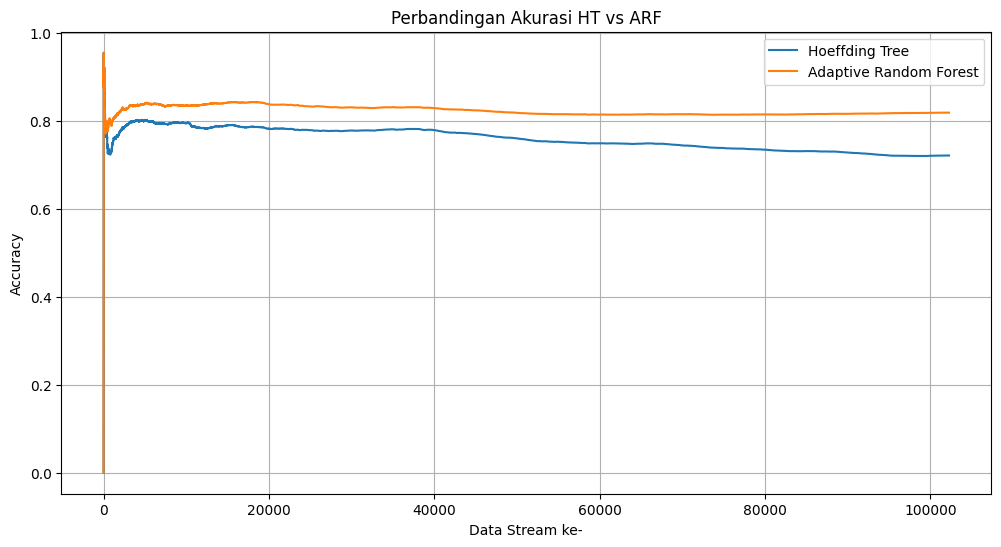

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    data_ke_ht,
    akurasi_ht_list,
    label='Hoeffding Tree'
)

plt.plot(
    data_ke,
    akurasi_list,
    label='Adaptive Random Forest'
)

plt.xlabel('Data Stream ke-')
plt.ylabel('Accuracy')

plt.title('Perbandingan Akurasi HT vs ARF')

plt.legend()

plt.grid(True)

plt.show()

## VISUALISASI BAR METRIK EVALUASI

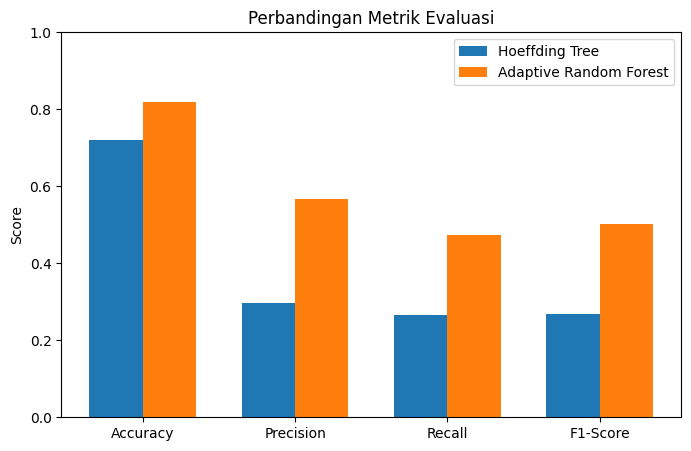

In [ ]:
metrik = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

ht_values = [
    metric_ht.get(),
    precision_ht.get(),
    recall_ht.get(),
    f1_ht.get()
]

arf_values = [
    metric_arf.get(),
    precision_arf.get(),
    recall_arf.get(),
    f1_arf.get()
]

x = np.arange(len(metrik))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x - width/2,
    ht_values,
    width,
    label='Hoeffding Tree'
)

plt.bar(
    x + width/2,
    arf_values,
    width,
    label='Adaptive Random Forest'
)

plt.xticks(x, metrik)

plt.ylabel('Score')

plt.title('Perbandingan Metrik Evaluasi')

plt.legend()

plt.ylim(0,1)

plt.show()

# **Analisis Geospasial Gempa Bumi Indonesia**

### 1. Menentukan Wilayah Gempa

Untuk mempermudah analisis, lokasi gempa dikelompokkan menjadi beberapa wilayah berdasarkan nilai longitude, yaitu Sumatera, Jawa-Bali, Kalimantan, Sulawesi, Maluku, dan Papua.

In [ ]:
print("===RINGKASAN DISTRIBUSI TINGKAT BAHAYA GEMPA===")
def tentukan_wilayah(lon):

    if lon < 106:
        return "Sumatera"

    elif lon < 116:
        return "Jawa-Bali"

    elif lon < 119:
        return "Kalimantan"

    elif lon < 125:
        return "Sulawesi"

    elif lon < 132:
        return "Maluku"

    else:
        return "Papua"


data["wilayah"] = data["longitude"].apply(tentukan_wilayah)

print("\nContoh hasil wilayah:")
print(data[['longitude', 'wilayah']].head())

===RINGKASAN DISTRIBUSI TINGKAT BAHAYA GEMPA===

Contoh hasil wilayah:
    longitude    wilayah
0  120.303391   Sulawesi
1  120.411621   Sulawesi
2  113.839798  Jawa-Bali
3  129.363144     Maluku
4  113.325302  Jawa-Bali


### 2. Statistik Gempa per Wilayah

Kami menghitung jumlah gempa, rata-rata magnitudo, serta magnitudo maksimum pada setiap wilayah.

Analisis ini bertujuan mengetahui wilayah mana yang memiliki aktivitas gempa paling tinggi.

In [ ]:
ringkasan_wilayah = (
    data.groupby("wilayah")
    .agg(
        jumlah_gempa=("magnitude", "count"),
        rata_magnitude=("magnitude", "mean"),
        magnitude_maks=("magnitude", "max")
    )
    .round(2)
)

print(ringkasan_wilayah)

            jumlah_gempa  rata_magnitude  magnitude_maks
wilayah                                                 
Jawa-Bali          12373            3.37            7.89
Kalimantan          9853            3.11            7.11
Maluku             26129            3.77            7.74
Papua               7189            3.66            7.45
Sulawesi           31974            3.17            7.52
Sumatera           14739            3.49            7.04


### 3. Distribusi Tingkat Bahaya per Wilayah

In [ ]:
distribusi_wilayah = pd.crosstab(
    data["wilayah"],
    data["tingkat_bahaya"]
)

urutan = ["Rendah", "Sedang", "Tinggi", "Ekstrem"]

for col in urutan:
    if col not in distribusi_wilayah.columns:
        distribusi_wilayah[col] = 0

distribusi_wilayah = distribusi_wilayah[urutan]

print(distribusi_wilayah)

tingkat_bahaya  Rendah  Sedang  Tinggi  Ekstrem
wilayah                                        
Jawa-Bali         4464    7247     659        3
Kalimantan        4919    4762     171        1
Maluku            4234   20944     938       13
Papua             1420    5564     204        1
Sulawesi         14339   17115     515        5
Sumatera          4017   10150     570        2


Secara keseluruhan, hasil analisis menunjukkan bahwa Sulawesi dan Maluku merupakan wilayah dengan aktivitas kegempaan paling tinggi, baik dari sisi jumlah kejadian maupun distribusi tingkat bahayanya. Kondisi ini sejalan dengan posisi geografis kedua wilayah yang berada pada kawasan pertemuan beberapa lempeng tektonik aktif, sehingga memiliki tingkat kerawanan gempa yang lebih tinggi dibandingkan wilayah lainnya di Indonesia.


### 4. Visualisasi Distribusi Gempa per Wilayah

<Figure size 1200x600 with 0 Axes>

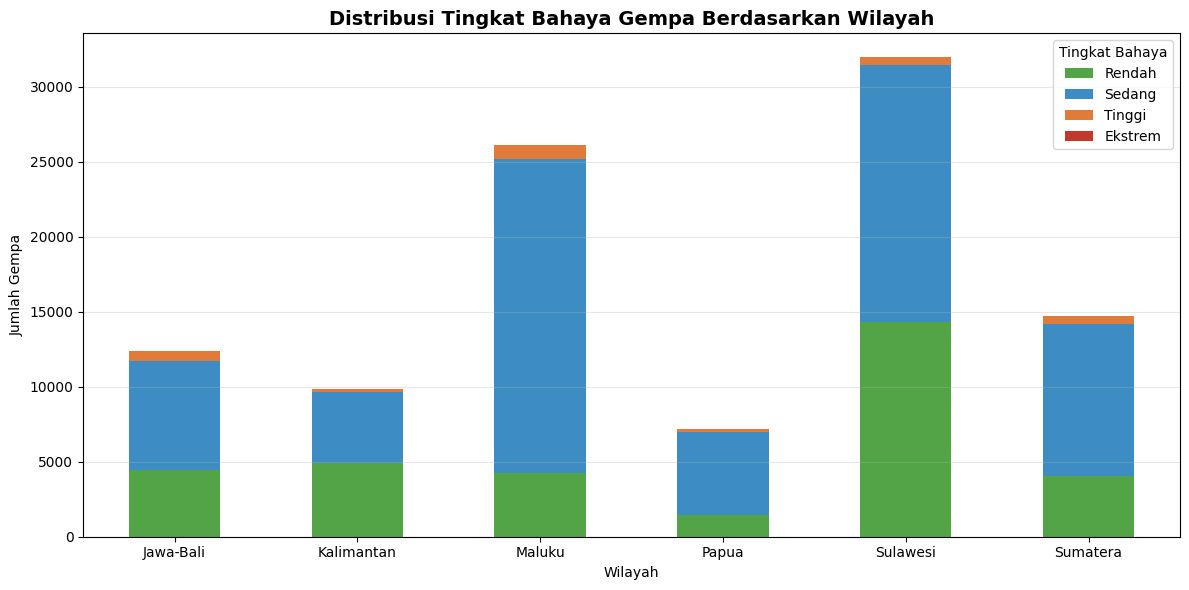

In [ ]:
warna = { 'Rendah' : '#52a447', 'Sedang' : '#3d8dc4', 'Tinggi' : '#e07b3a', 'Ekstrem': '#c0392b' }

plt.figure(figsize=(12,6))

distribusi_wilayah.plot( kind='bar', stacked=True, color=[warna[k] for k in distribusi_wilayah.columns], figsize=(12,6) )

plt.title( 'Distribusi Tingkat Bahaya Gempa Berdasarkan Wilayah', fontsize=14, fontweight='bold' )
plt.xlabel('Wilayah')
plt.ylabel('Jumlah Gempa')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Tingkat Bahaya')
plt.tight_layout()
plt.show()

### 5. Peta Sebaran Gempa Indonesia

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


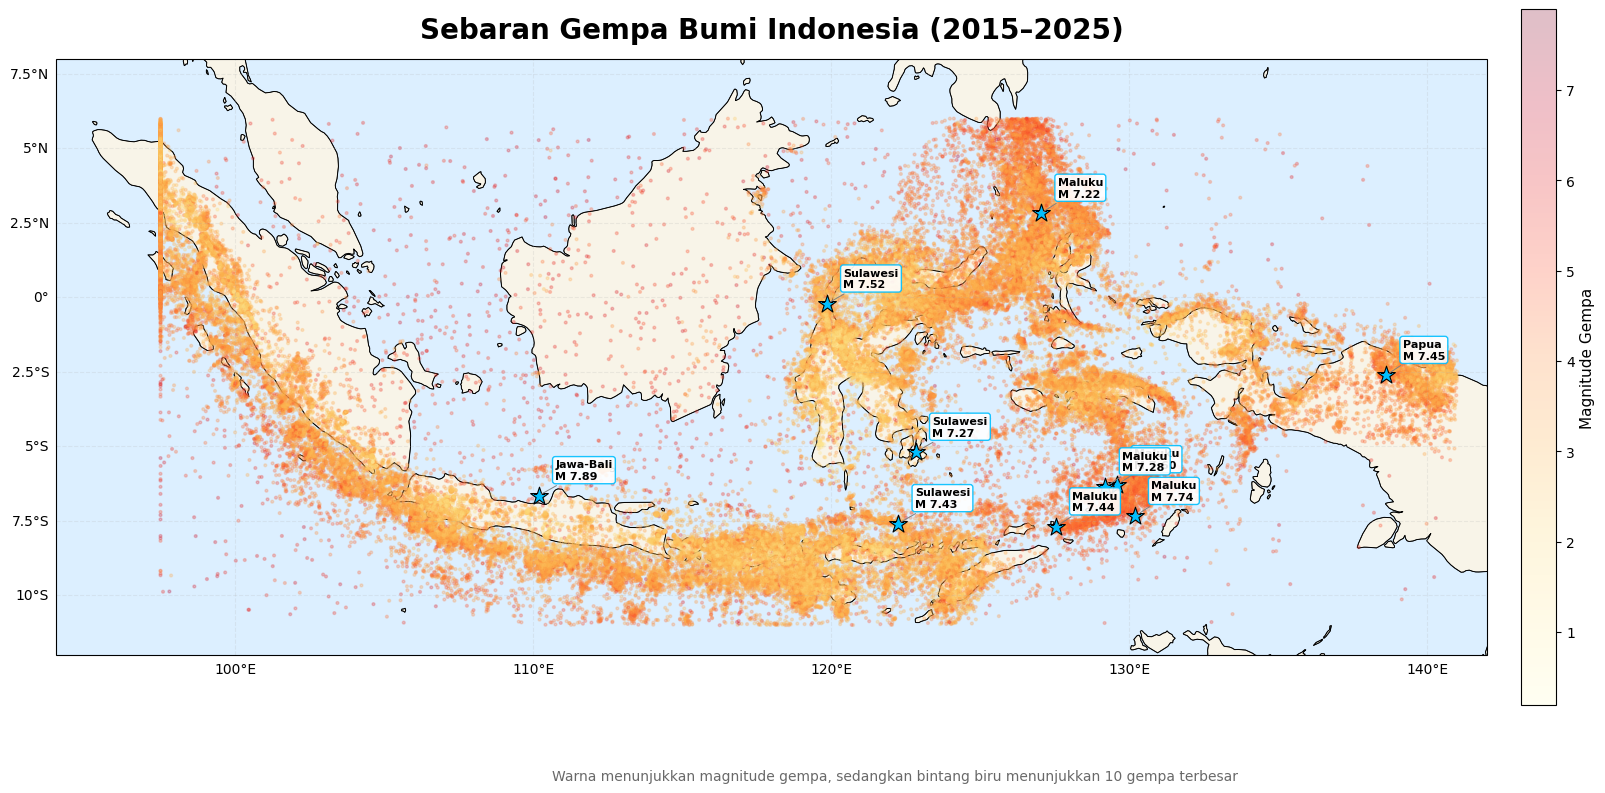

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# TOP 10 GEMPA TERBESAR

top10 = data.nlargest(10, "magnitude")

# FIGURE

fig = plt.figure(figsize=(18,9))

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

ax.set_extent(
    [94,142,-12,8],
    crs=ccrs.PlateCarree()
)

# AMBIL KOLOM LOKASI

def ambil_lokasi(row):

    kandidat = [
        'location',
        'place',
        'region',
        'remark',
        'wilayah',
        'Lokasi'
    ]

    for kolom in kandidat:

        if kolom in row.index:

            val = str(row[kolom])

            if pd.notna(row[kolom]) and val.strip() != '':
                return val

    return 'Tidak diketahui'

top10['Lokasi'] = top10.apply(
    ambil_lokasi,
    axis=1
)

# BASEMAP

ax.add_feature(
    cfeature.OCEAN,
    facecolor="#dcefff"
)

ax.add_feature(
    cfeature.LAND,
    facecolor="#f8f4e8",
    edgecolor="black",
    linewidth=0.4
)

ax.add_feature(
    cfeature.COASTLINE,
    linewidth=0.7
)

# GEMPA

scatter = ax.scatter(
    data["longitude"],
    data["latitude"],

    c=data["magnitude"],
    cmap="YlOrRd",

    s=4,
    alpha=0.25,

    transform=ccrs.PlateCarree(),
    zorder=2
)

# TOP 10 GEMPA

ax.scatter(
    top10["longitude"],
    top10["latitude"],

    marker="*",
    s=180,

    color="deepskyblue",
    edgecolor="black",
    linewidth=0.8,

    transform=ccrs.PlateCarree(),
    zorder=10
)

# LABEL LOKASI TOP 10 GEMPA TERBESAR

for _, row in top10.head(10).iterrows():

    ax.annotate(
        f"{row['Lokasi']}\nM {row['magnitude']:.2f}",

        xy=(
            row["longitude"],
            row["latitude"]
        ),

        xytext=(12, 12),

        textcoords="offset points",

        fontsize=8,
        fontweight="bold",

        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="deepskyblue",
            alpha=0.9
        ),

        arrowprops=dict(
            arrowstyle="-",
            color="gray",
            lw=0.7
        ),

        zorder=11
    )

# COLORBAR

cbar = plt.colorbar(
    scatter,
    ax=ax,
    shrink=0.8,
    pad=0.02
)

cbar.set_label(
    "Magnitude Gempa",
    fontsize=11
)

# GRID

gl = ax.gridlines(
    draw_labels=True,
    linestyle="--",
    alpha=0.2
)

gl.top_labels = False
gl.right_labels = False

# TITLE

plt.title(
    "Sebaran Gempa Bumi Indonesia (2015–2025)",
    fontsize=20,
    fontweight="bold",
    pad=15
)

# FOOTNOTE

plt.figtext(
    0.5,
    0.03,

    "Warna menunjukkan magnitude gempa, sedangkan bintang biru menunjukkan 10 gempa terbesar",

    ha="center",
    fontsize=10,
    color="dimgray"
)

plt.tight_layout()
plt.show()

Visualisasi ini menunjukkan persebaran gempa bumi di Indonesia selama periode 2015 hingga 2025 berdasarkan koordinat latitude dan longitude.

Setiap titik merepresentasikan satu kejadian gempa. Warna titik menunjukkan magnitudo gempa, di mana semakin gelap warnanya maka semakin besar magnitudo gempa tersebut.

Dari peta terlihat bahwa aktivitas gempa tidak tersebar merata, melainkan terkonsentrasi pada jalur pertemuan lempeng tektonik atau Ring of Fire Indonesia.

Kepadatan gempa paling tinggi terlihat di sepanjang pantai barat Sumatra, selatan Jawa hingga Nusa Tenggara, Sulawesi, Maluku, dan Papua. Hal ini sesuai dengan kondisi geologi Indonesia yang berada pada pertemuan beberapa lempeng besar dunia.

Selain itu, bintang berwarna biru menunjukkan 10 gempa dengan magnitudo terbesar dalam dataset. Sebagian besar gempa besar tersebut berada di wilayah Jawa-Bali, Sulawesi, Maluku, dan Papua dengan magnitudo di atas 7.

### 6. Tren Gempa Tinggi & Ekstrem

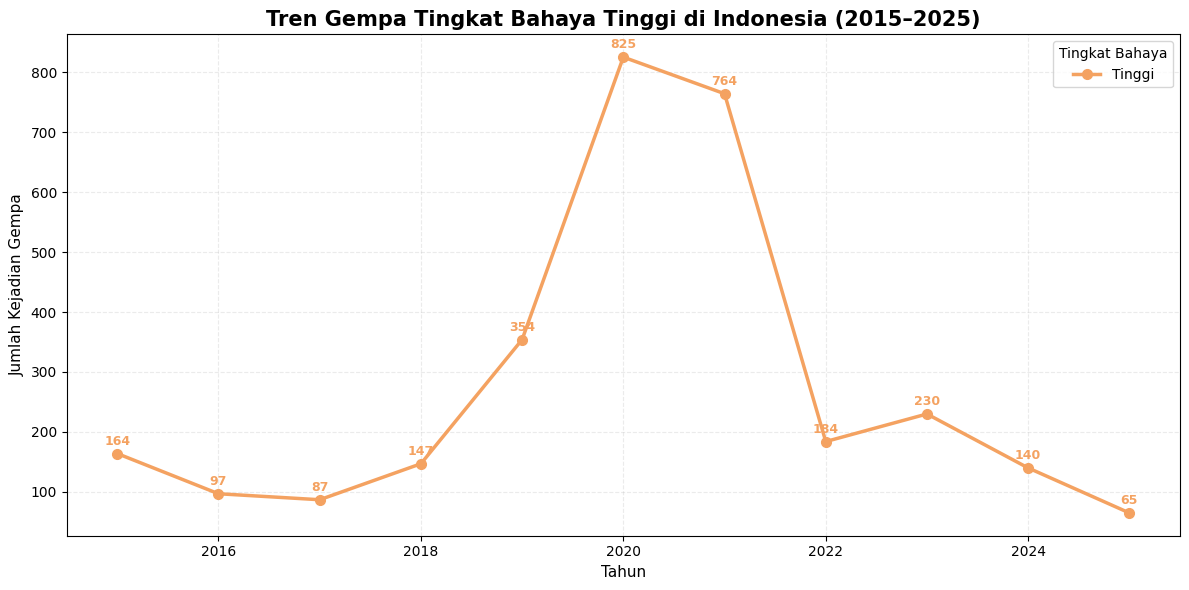

In [ ]:
gempa_bahaya = data[
    data['tingkat_bahaya'].isin(['Tinggi'])
]

tren_tahun = pd.crosstab(
    gempa_bahaya['year'],
    gempa_bahaya['tingkat_bahaya']
)

plt.figure(figsize=(12,6))

warna = {
    'Tinggi': '#f4a261',
    'Ekstrem': '#d62828'
}

for col in tren_tahun.columns:

    plt.plot(
        tren_tahun.index,
        tren_tahun[col],

        marker='o',
        markersize=7,

        linewidth=2.5,

        label=col,

        color=warna[col]
    )

    # TAMPILKAN ANGKA DI SETIAP TITIK

    for x, y in zip(
        tren_tahun.index,
        tren_tahun[col]
    ):

        plt.text(
            x,
            y + 15,

            str(y),

            ha='center',
            fontsize=9,
            fontweight='bold',
            color=warna[col]
        )

# JUDUL

plt.title(
    'Tren Gempa Tingkat Bahaya Tinggi di Indonesia (2015–2025)',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel(
    'Tahun',
    fontsize=11
)

plt.ylabel(
    'Jumlah Kejadian Gempa',
    fontsize=11
)

# GRID

plt.grid(
    alpha=0.25,
    linestyle='--'
)

plt.legend(
    title='Tingkat Bahaya'
)

plt.tight_layout()
plt.show()

### 7. Top 10 Gempa Terbesar + Prediksi Model

In [ ]:
top_gempa = data.nlargest(10, 'magnitude').copy()

# Prediksi model
top_gempa['Prediksi_HT'] = (
    df_prediksi.loc[
        top_gempa.index,
        'label_prediksi'
    ]
)

top_gempa['Prediksi_ARF'] = (
    df_prediksi_arf.loc[
        top_gempa.index,
        'label_prediksi'
    ]
)

# Tahun
top_gempa['Tahun'] = pd.to_datetime(
    top_gempa['datetime']
).dt.year

# AMBIL LOKASI TERBAIK

def ambil_lokasi(row):

    kandidat = [
        'location',
        'place',
        'region',
        'remark',
        'wilayah'
    ]

    for kolom in kandidat:

        if kolom in row.index:

            val = str(row[kolom])

            if pd.notna(row[kolom]) and val.strip() != '':
                return val

    return 'Tidak diketahui'

top_gempa['Lokasi'] = top_gempa.apply(
    ambil_lokasi,
    axis=1
)

# TABEL AKHIR

hasil_top10 = top_gempa[
    [
        'Tahun',
        'Lokasi',
        'magnitude',
        'Prediksi_HT',
        'Prediksi_ARF'
    ]
].rename(
    columns={
        'magnitude': 'Magnitude'
    }
)

hasil_top10['Magnitude'] = hasil_top10[
    'Magnitude'
].round(2)

display(hasil_top10)

,Tahun,Lokasi,Magnitude,Prediksi_HT,Prediksi_ARF
43415,2020,Jawa-Bali,7.89,Sedang,Sedang
70004,2023,Maluku,7.74,Sedang,Sedang
79027,2023,Maluku,7.60,Sedang,Sedang
25389,2018,Sulawesi,7.52,Sedang,Sedang
32860,2019,Papua,7.45,Sedang,Sedang
59215,2021,Maluku,7.44,Sedang,Sedang
58287,2021,Sulawesi,7.43,Sedang,Sedang
32861,2019,Maluku,7.28,Sedang,Tinggi
44648,2020,Sulawesi,7.27,Sedang,Sedang
70290,2023,Maluku,7.22,Sedang,Sedang


Karena model tidak menggunakan magnitude sebagai fitur untuk menghindari data leakage. Model hanya menggunakan informasi lokasi, kedalaman, phasecount, dan waktu kejadian. Oleh karena itu masih terdapat beberapa kesalahan klasifikasi, terutama pada kelas Ekstrem yang jumlah datanya lebih sedikit dibanding kelas lainnya.